In [10]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install -q torch-geometric -f https://data.pyg.org/whl/torch-{torch_version}.html
!pip install optuna

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [11]:
import torch
from torch_geometric.utils import degree
from torch_geometric.utils import subgraph
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import negative_sampling
import random
import community.community_louvain as community_louvain
import sys
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
import torch_geometric
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import json
import optuna
from torch_geometric.utils import to_dense_adj
from torch_geometric.nn import Node2Vec, GCNConv, GATConv
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score
from torch_geometric.utils import to_networkx
import torch.nn.functional as F
from IPython.display import HTML
from torch_geometric.data import Data
from networkx.algorithms import community
from optuna.visualization import plot_optimization_history, plot_param_importances
from sklearn.metrics import silhouette_score
import logging
import gc
from matplotlib.patches import Patch

optuna.logging.set_verbosity(optuna.logging.INFO)

%matplotlib inline

# Configuración de la semilla para reproducibilidad
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


# **IMPORTACIÓN Y VISUALIZACIÓN DE LA DATA**

In [13]:
dataset = Amazon(root='data/Amazon', name='Computers')

data = dataset[0]
print(f'Dataset: {dataset}:')
print('======================')
print(f'Número de nodos: {data.num_nodes}')
print(f'Número de aristas: {data.num_edges}')
print(f'Número de clases: {dataset.num_classes}')
print(f'Dimensión de características: {dataset.num_features}')
print("\n")
data

Dataset: AmazonComputers():
Número de nodos: 13752
Número de aristas: 491722
Número de clases: 10
Dimensión de características: 767




Data(x=[13752, 767], edge_index=[2, 491722], y=[13752])

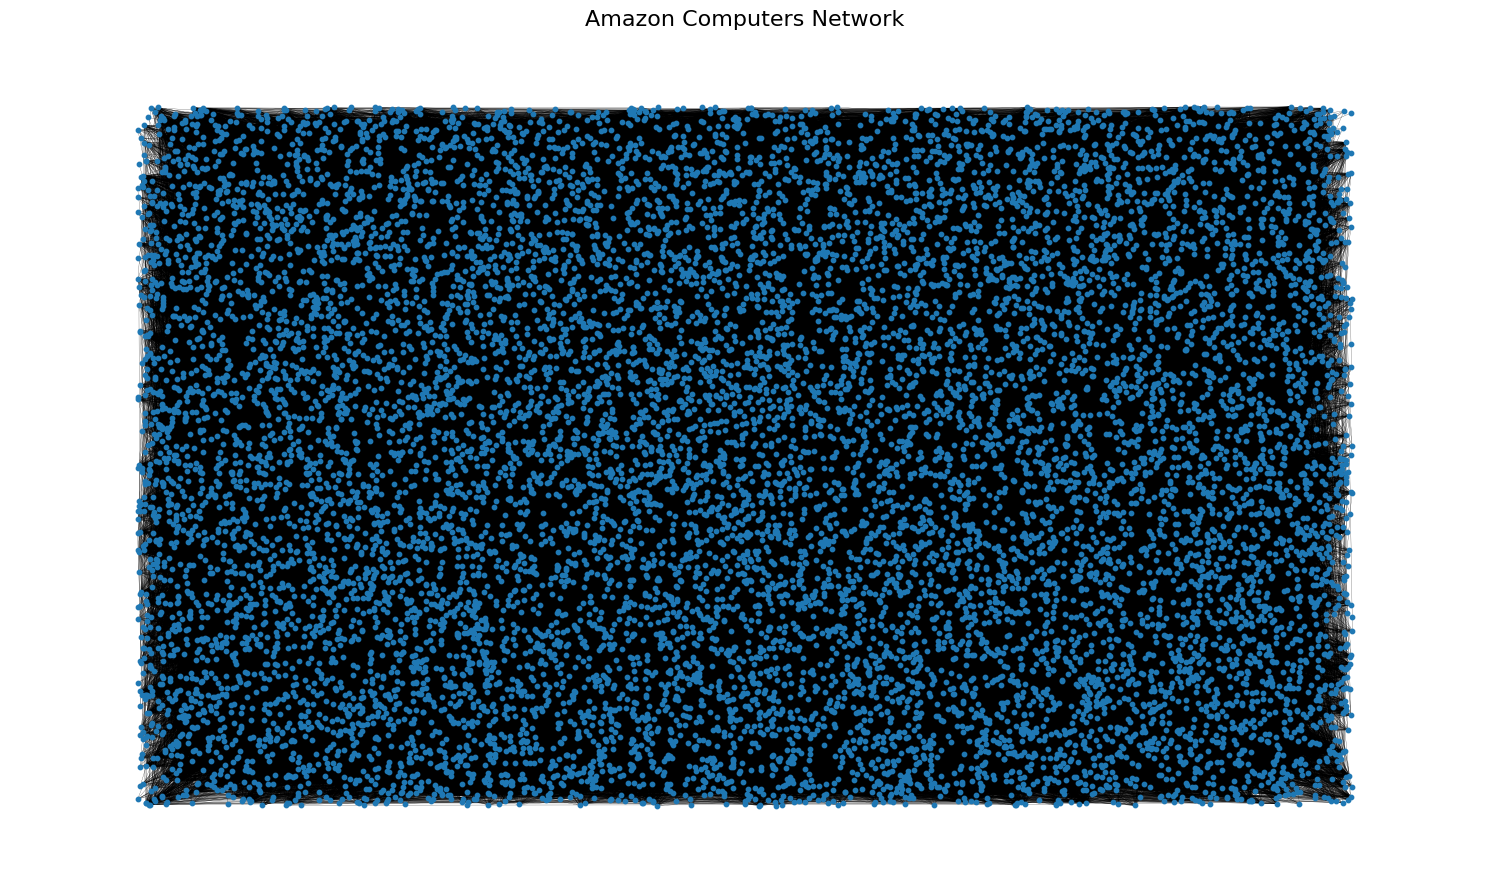

In [ ]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}

nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)
plt.title("Amazon Computers Network", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
nodes_data = []
for node_id in range(min(5000, data.num_nodes)):
    if node_id < len(data.y):
        group = int(data.y[node_id].item())
    else:
        group = 0

    nodes_data.append({
        "id": str(node_id),
        "group": group
    })

edges_data = []
for edge in edge_index_list.values:
    source, target = edge
    if source < 5000 and target < 5000:
        edges_data.append({
            "source": str(source),
            "target": str(target)
        })

graph_data = {
    "nodes": nodes_data,
    "links": edges_data
}

graph_json = json.dumps(graph_data)

html_code = f"""
<!DOCTYPE html>
<html>
<head>
    <style> body {{ margin: 0; }} </style>
    <script src="https://unpkg.com/3d-force-graph@1.70.5/dist/3d-force-graph.min.js"></script>
</head>
<body>
    <div id="3d-graph" style="width: 100%; height: 600px;"></div>

    <script>
        // Parse the data
        const graphData = {graph_json};

        // Node colors based on group
        const colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'];

        // Initialize the 3D force graph
        const Graph = ForceGraph3D()
            (document.getElementById('3d-graph'))
            .graphData(graphData)
            .nodeColor(node => colors[node.group % colors.length])
            .nodeRelSize(3)
            .linkWidth(0.2)
            .linkOpacity(0.5)
            .backgroundColor('#FFFFFF')
            .nodeLabel(node => `Node ${{node.id}}`)
            .linkDirectionalParticles(1)
            .linkDirectionalParticleWidth(0.5)
            .enableNodeDrag(true)
            .enableNavigationControls(true)
            .showNavInfo(true);

        // Handle window resize
        window.addEventListener('resize', () => {{
            Graph.width(document.getElementById('3d-graph').clientWidth)
                .height(document.getElementById('3d-graph').clientHeight);
        }});

        // Instructions
        console.log("Navigation controls: Left-click + drag to rotate, right-click + drag to pan, scroll to zoom");
    </script>
</body>
</html>
"""

HTML(html_code)

# **ANALISIS EXPLORATORIO**

PROPIEDADES TOPOLÓGICAS BÁSICAS

In [ ]:
G = to_networkx(data, to_undirected=True)

print("\n== PROPIEDADES TOPOLÓGICAS BÁSICAS ==")
print(f"Total de nodos: {G.number_of_nodes()}")
print(f"Total de aristas: {data.num_edges}")
print(f"Total de aristas únicas: {G.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G):.8f}")
print(f"¿Es conexo? {nx.is_connected(G)}")

num_components = nx.number_connected_components(G)
print(f"Número de componentes conexas: {num_components}")

components = list(nx.connected_components(G))
component_sizes = [len(c) for c in components]
print(f"Tamaño de las componentes: {component_sizes}")

avg_degree = np.mean([d for _, d in G.degree()])
print(f"Grado promedio: {avg_degree:.4f}")


== PROPIEDADES TOPOLÓGICAS BÁSICAS ==
Total de nodos: 13752
Total de aristas: 491722
Total de aristas únicas: 245861
Densidad del grafo: 0.00260028
¿Es conexo? False
Número de componentes conexas: 314
Tamaño de las componentes: [13381, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 7, 1, 2, 1, 1, 1, 3, 1, 1, 3, 1, 2, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 4, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

ANÁLISIS DE CAMINOS


In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()
print(f"Tamaño de la componente gigante: {len(largest_cc)} nodos")

print("Calculando una aproximación mediante muestreo...")

sampled_nodes = np.random.choice(list(G_lcc.nodes()), min(1300, len(G_lcc)), replace=False)
max_path = 0
for node in sampled_nodes:
    paths = nx.single_source_shortest_path_length(G_lcc, node)
    if max(paths.values()) > max_path:
        max_path = max(paths.values())
print(f"Diámetro aproximado (muestreado): {max_path}")


print("Calculando longitud media de caminos mediante muestreo...")

sampled_nodes = np.random.choice(list(G_lcc.nodes()), min(1300, len(G_lcc)), replace=False)
path_lengths = []
for node in sampled_nodes:
    paths = nx.single_source_shortest_path_length(G_lcc, node)
    path_lengths.extend(list(paths.values()))
avg_path_length = np.mean(path_lengths)
print(f"Longitud media de caminos más cortos (muestreada): {avg_path_length:.4f}")


Tamaño de la componente gigante: 13381 nodos
Calculando una aproximación mediante muestreo...
Diámetro aproximado (muestreado): 10
Calculando longitud media de caminos mediante muestreo...
Longitud media de caminos más cortos (muestreada): 3.3949


MEDIDAS DE CENTRALIDAD

In [ ]:
if G.number_of_nodes() > 5000:
    print("Grafo grande detectado, usando una muestra de nodos para cálculos de centralidad...")
    sample_size = min(1000, len(largest_cc))
    sampled_nodes = list(np.random.choice(list(largest_cc), sample_size, replace=False))
    G_sample = G.subgraph(sampled_nodes).copy()
    print(f"Muestra de {len(G_sample)} nodos seleccionada.")
else:
    G_sample = G_lcc

print("Calculando centralidad de grado...")
degree_centrality = nx.degree_centrality(G_sample)
print("Top 10 nodos con mayor centralidad de grado:")
sorted_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_degree:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de intermediación (betweenness)...")
if len(G_sample) > 500:
    print("  Usando una muestra más pequeña para betweenness...")
    betweenness_sample = list(np.random.choice(list(G_sample.nodes()), min(500, len(G_sample)), replace=False))
    G_small_sample = G_sample.subgraph(betweenness_sample).copy()
    betweenness_centrality = nx.betweenness_centrality(G_small_sample, k=min(100, len(G_small_sample)))
else:
    betweenness_centrality = nx.betweenness_centrality(G_sample)

print("Top 10 nodos con mayor centralidad de intermediación:")
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_betweenness:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de cercanía (closeness)...")
if len(G_sample) > 500:
    closeness_centrality = nx.closeness_centrality(G_small_sample)
else:
    closeness_centrality = nx.closeness_centrality(G_sample)

print("Top 10 nodos con mayor centralidad de cercanía:")
sorted_closeness = sorted(closeness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
for node, centrality in sorted_closeness:
    print(f"  Nodo {node}: {centrality:.6f}")

print("\nCalculando centralidad de vector propio (eigenvector)...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(G_sample, max_iter=100)
    print("Top 10 nodos con mayor centralidad de vector propio:")
    sorted_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
    for node, centrality in sorted_eigenvector:
        print(f"  Nodo {node}: {centrality:.6f}")
except:
    print("  El cálculo de eigenvector centrality no convergió. Intentando con power iteration...")
    try:
        eigenvector_centrality = nx.eigenvector_centrality_numpy(G_sample)
        print("Top 10 nodos con mayor centralidad de vector propio:")
        sorted_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
        for node, centrality in sorted_eigenvector:
            print(f"  Nodo {node}: {centrality:.6f}")
    except:
        print("  No se pudo calcular la centralidad de vector propio.")


Grafo grande detectado, usando una muestra de nodos para cálculos de centralidad...
Muestra de 1000 nodos seleccionada.
Calculando centralidad de grado...
Top 10 nodos con mayor centralidad de grado:
  Nodo 2138: 0.066066
  Nodo 12717: 0.044044
  Nodo 6418: 0.028028
  Nodo 5908: 0.028028
  Nodo 5598: 0.027027
  Nodo 8299: 0.026026
  Nodo 5967: 0.024024
  Nodo 10110: 0.023023
  Nodo 4316: 0.022022
  Nodo 4222: 0.021021

Calculando centralidad de intermediación (betweenness)...
  Usando una muestra más pequeña para betweenness...
Top 10 nodos con mayor centralidad de intermediación:
  Nodo 12717: 0.057992
  Nodo 4316: 0.044592
  Nodo 4769: 0.043149
  Nodo 11128: 0.040964
  Nodo 9307: 0.027163
  Nodo 1380: 0.026134
  Nodo 2245: 0.025189
  Nodo 9072: 0.023078
  Nodo 6600: 0.022978
  Nodo 325: 0.022617

Calculando centralidad de cercanía (closeness)...
Top 10 nodos con mayor centralidad de cercanía:
  Nodo 12717: 0.094714
  Nodo 8299: 0.092564
  Nodo 4316: 0.089690
  Nodo 4769: 0.089000
  N

DISTRIBUCIÓN DE GRADOS

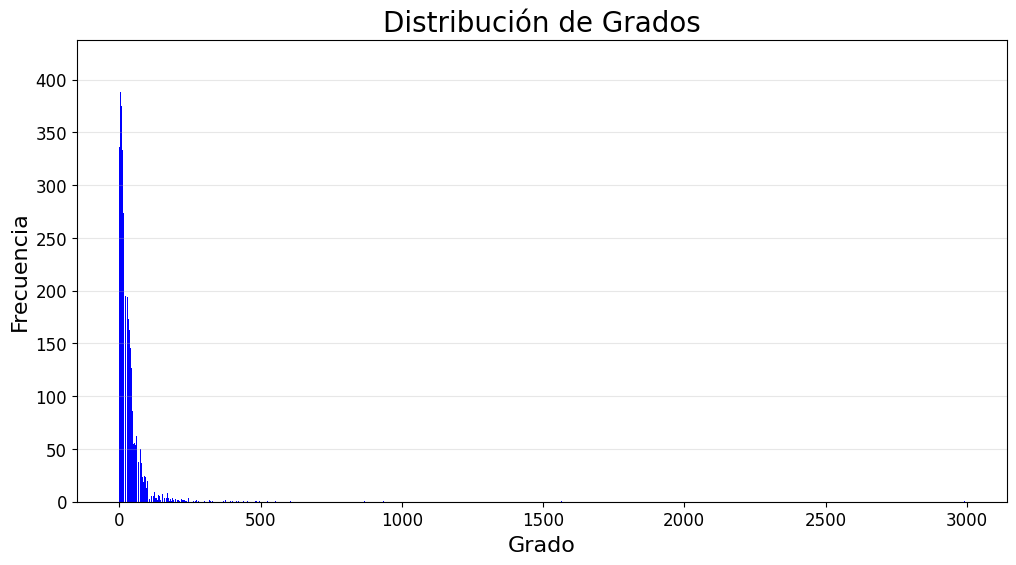

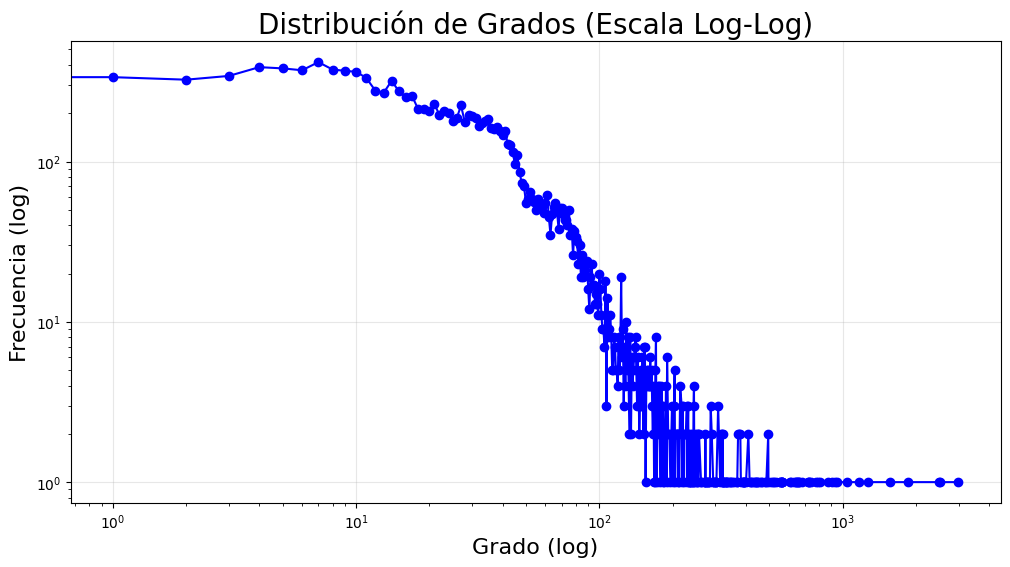

In [ ]:
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
degree_count = np.bincount(degree_sequence)
degree_values = np.arange(len(degree_count))

plt.figure(figsize=(12, 6))
plt.bar(degree_values, degree_count, width=0.80, color="b")
plt.title("Distribución de Grados", fontsize=20)
plt.ylabel("Frecuencia", fontsize=16)
plt.xlabel("Grado", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.loglog(degree_values[degree_count > 0], degree_count[degree_count > 0], 'bo-')
plt.title("Distribución de Grados (Escala Log-Log)", fontsize=20)
plt.ylabel("Frecuencia (log)", fontsize=16)
plt.xlabel("Grado (log)", fontsize=16)
plt.grid(alpha=0.3)
plt.show()


COEFICIENTE DE CLUSTERING Y TRANSITIVIDAD


== CLUSTERING Y TRANSITIVIDAD ==
Calculando coeficiente de clustering global...
Transitividad global (fracción de triángulos): 0.107739
Calculando coeficiente de clustering promedio...
Coeficiente de clustering promedio: 0.344126
Calculando distribución de coeficientes de clustering...


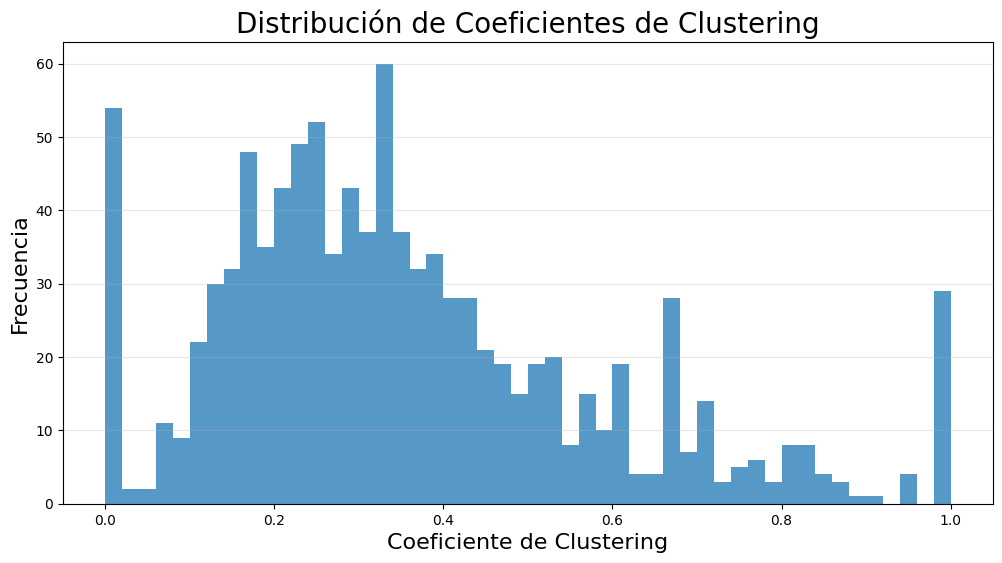

In [ ]:

print("\n== CLUSTERING Y TRANSITIVIDAD ==")
print("Calculando coeficiente de clustering global...")
transitivity = nx.transitivity(G)
print(f"Transitividad global (fracción de triángulos): {transitivity:.6f}")

print("Calculando coeficiente de clustering promedio...")
avg_clustering = nx.average_clustering(G)
print(f"Coeficiente de clustering promedio: {avg_clustering:.6f}")

print("Calculando distribución de coeficientes de clustering...")
if G.number_of_nodes() > 5000:
    sample_nodes = np.random.choice(list(G.nodes()), min(1000, G.number_of_nodes()), replace=False)
    clustering_coeffs = nx.clustering(G, nodes=sample_nodes)
else:
    clustering_coeffs = nx.clustering(G)

plt.figure(figsize=(12, 6))
plt.hist(list(clustering_coeffs.values()), bins=50, alpha=0.75)
plt.title("Distribución de Coeficientes de Clustering", fontsize=20)
plt.xlabel("Coeficiente de Clustering", fontsize=16)
plt.ylabel("Frecuencia", fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.show()

DETECCIÓN DE COMUNIDADES

Usando muestra de 1000 nodos para detección de comunidades
Detectando comunidades con el algoritmo de Louvain...
Número de comunidades detectadas: 352
Tamaño promedio de comunidad: 2.84 nodos
Tamaño mínimo de comunidad: 1 nodos
Tamaño máximo de comunidad: 96 nodos


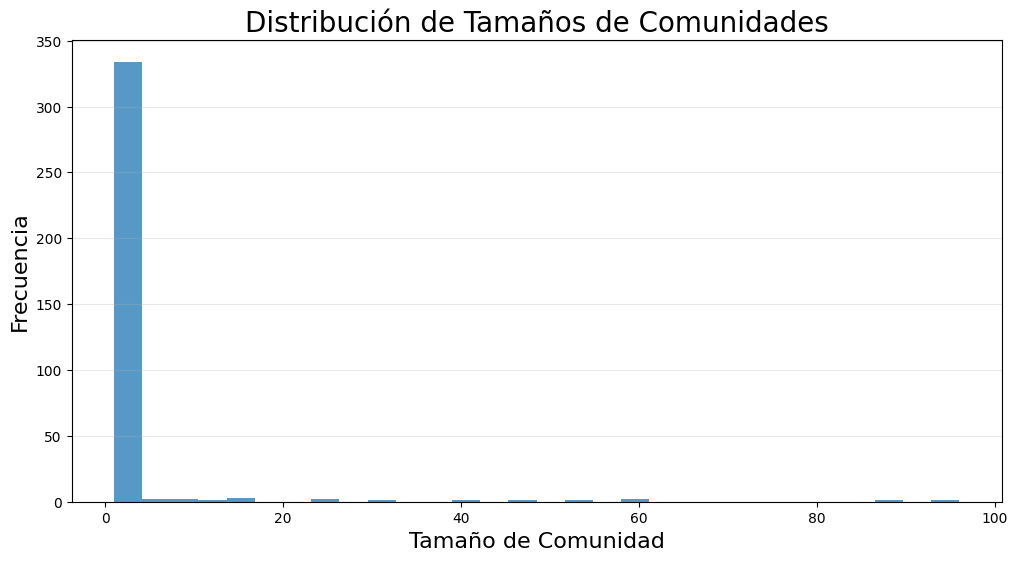

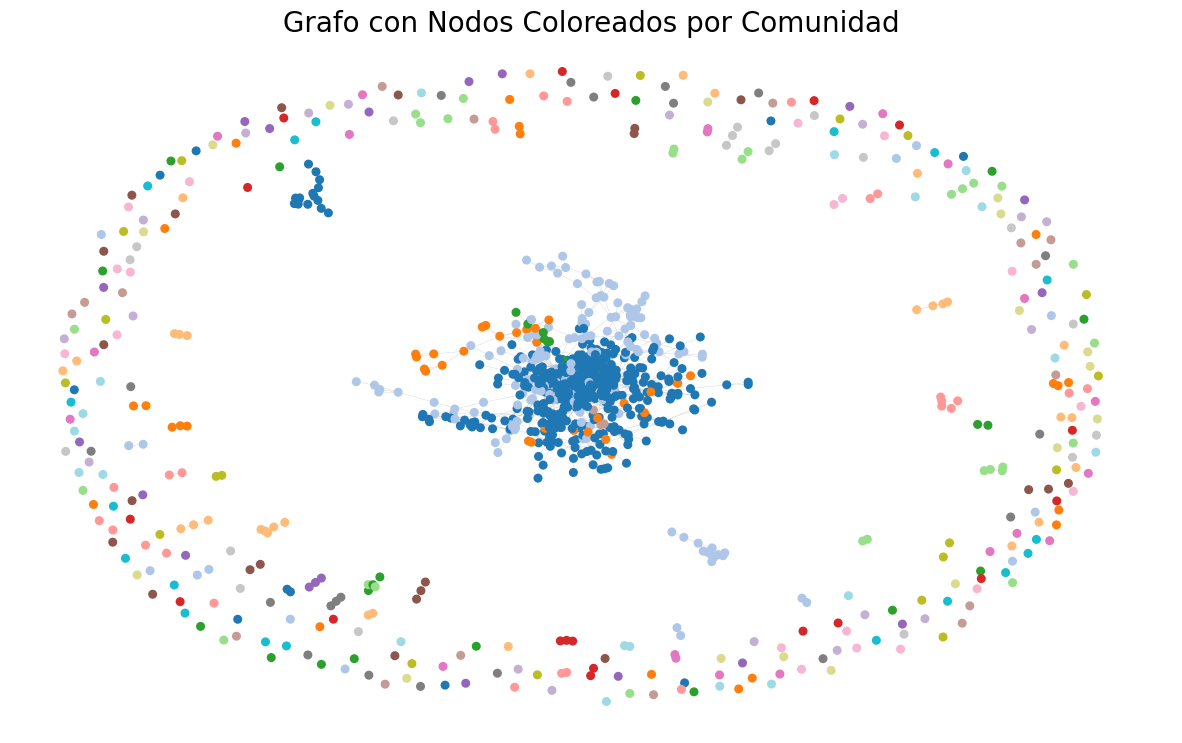

In [ ]:
if G.number_of_nodes() > 1000:
    community_graph = G_sample
    print(f"Usando muestra de {community_graph.number_of_nodes()} nodos para detección de comunidades")
else:
    community_graph = G
    print(f"Usando grafo completo ({community_graph.number_of_nodes()} nodos) para detección de comunidades")

try:
    print("Detectando comunidades con el algoritmo de Louvain...")
    partition = community_louvain.best_partition(community_graph)
    communities = {}
    for node, community_id in partition.items():
        if community_id not in communities:
            communities[community_id] = []
        communities[community_id].append(node)

    print(f"Número de comunidades detectadas: {len(communities)}")
    community_sizes = [len(nodes) for comm_id, nodes in communities.items()]
    print(f"Tamaño promedio de comunidad: {np.mean(community_sizes):.2f} nodos")
    print(f"Tamaño mínimo de comunidad: {min(community_sizes)} nodos")
    print(f"Tamaño máximo de comunidad: {max(community_sizes)} nodos")

    plt.figure(figsize=(12, 6))
    plt.hist(community_sizes, bins=30, alpha=0.75)
    plt.title("Distribución de Tamaños de Comunidades", fontsize=20)
    plt.xlabel("Tamaño de Comunidad", fontsize=16)
    plt.ylabel("Frecuencia", fontsize=16)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    if community_graph.number_of_nodes() <= 1000:
        plt.figure(figsize=(15, 9))
        colors = [partition[node] for node in community_graph.nodes()]
        nx.draw_networkx(
            community_graph,
            pos=nx.spring_layout(community_graph, seed=42),
            node_color=colors,
            node_size=30,
            with_labels=False,
            edge_color='gray',
            width=0.1,
            cmap=plt.cm.tab20
        )
        plt.title("Grafo con Nodos Coloreados por Comunidad", fontsize=20)
        plt.axis('off')
        plt.savefig('community_visualization.png', dpi=300, bbox_inches='tight')
        plt.show()
except ImportError:
    print("La librería 'community' no está instalada. Instalála con: pip install python-louvain")
    print("Usando algoritmo alternativo para detección de comunidades...")

    try:
        communities = community.greedy_modularity_communities(community_graph)
        print(f"Número de comunidades detectadas: {len(communities)}")
        community_sizes = [len(comm) for comm in communities]
        print(f"Tamaño promedio de comunidad: {np.mean(community_sizes):.2f} nodos")
        print(f"Tamaño mínimo de comunidad: {min(community_sizes)} nodos")
        print(f"Tamaño máximo de comunidad: {max(community_sizes)} nodos")
    except:
        print("No se pudo realizar la detección de comunidades.")

ANÁLISIS DE ASORTATIVIDAD

In [ ]:
print("Calculando coeficiente de asortatividad por grado...")
try:
    assortativity = nx.degree_assortativity_coefficient(G)
    print(f"Coeficiente de asortatividad: {assortativity:.6f}")

    if assortativity > 0.1:
        print("  El grafo es asortativo: nodos con grado similar tienden a conectarse entre sí.")
    elif assortativity < -0.1:
        print("  El grafo es disasortativo: nodos con grado diferente tienden a conectarse entre sí.")
    else:
        print("  El grafo no muestra un patrón claro de asortatividad.")
except:
    print("No se pudo calcular el coeficiente de asortatividad.")

Calculando coeficiente de asortatividad por grado...
Coeficiente de asortatividad: -0.056488
  El grafo no muestra un patrón claro de asortatividad.


IDENTIFICACIÓN DE BRIDGES (PUENTES)

Nodos con grado <= 4: 1671 de 13752 (12.15%)
Subgrafo filtrado: 1671 nodos y 258 aristas
Muestra del subgrafo filtrado: 1000 nodos y 103 aristas
El subgrafo filtrado tiene 900 componentes conexas
Tamaño de las 5 componentes más grandes: [5, 5, 5, 4, 4]
Buscando puentes en el grafo filtrado...
Número de puentes encontrados: 94
Ejemplo de puentes: [(6162, 12311), (4140, 7765), (4141, 9346), (6193, 4864), (2106, 4963)]
Número de nodos que forman parte de puentes: 169
Porcentaje de nodos del subgrafo: 16.90%
Distribución de grados de nodos en puentes:
  Grado 1: 32 nodos (18.93%)
  Grado 2: 42 nodos (24.85%)
  Grado 3: 48 nodos (28.40%)
  Grado 4: 47 nodos (27.81%)


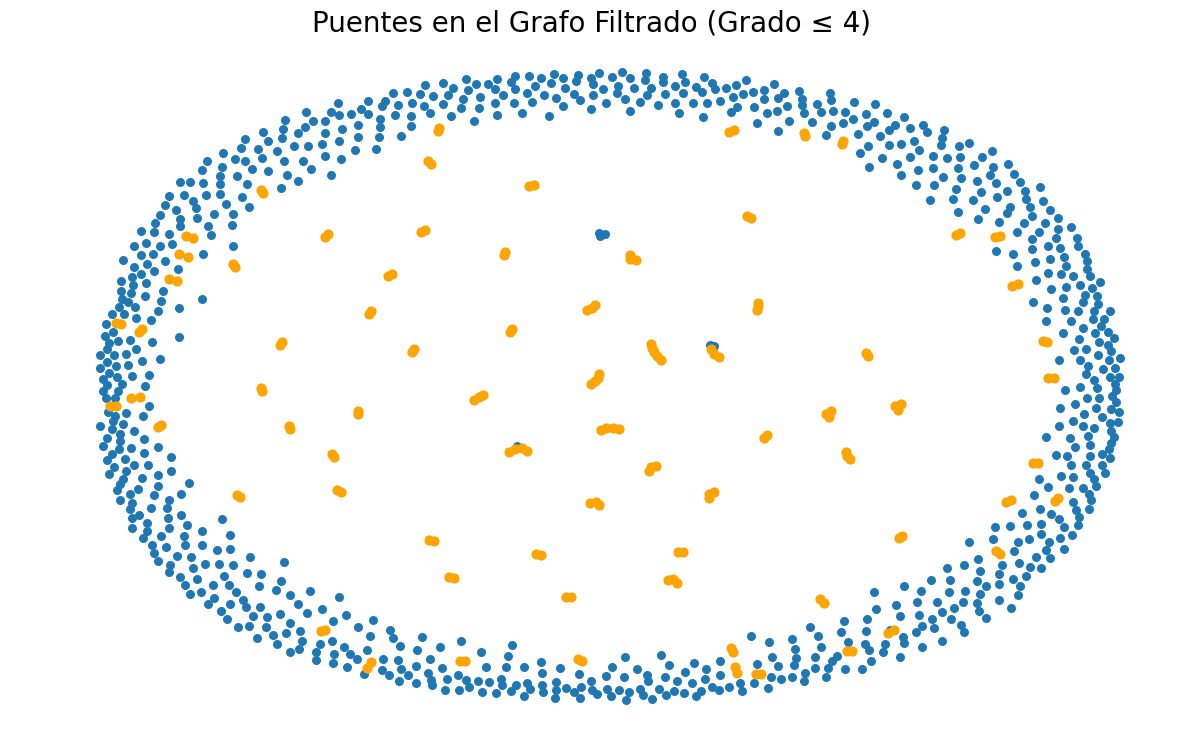

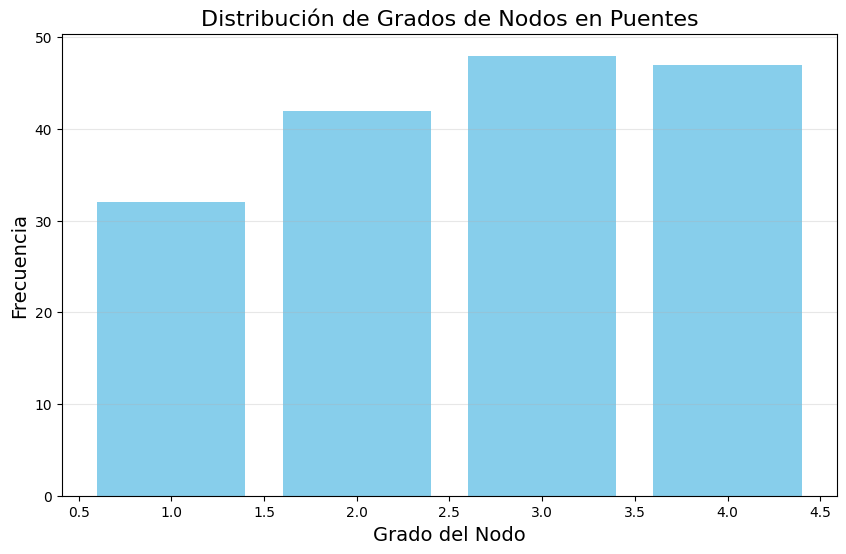

In [ ]:
node_degrees = dict(G.degree())

max_degree_threshold = 4

low_degree_nodes = [node for node, degree in node_degrees.items() if degree <= max_degree_threshold]
print(f"Nodos con grado <= {max_degree_threshold}: {len(low_degree_nodes)} de {G.number_of_nodes()} ({len(low_degree_nodes)/G.number_of_nodes()*100:.2f}%)")

G_filtered = G.subgraph(low_degree_nodes)
print(f"Subgrafo filtrado: {G_filtered.number_of_nodes()} nodos y {G_filtered.number_of_edges()} aristas")

if G_filtered.number_of_nodes() > 1000:
    sample_size = 1000
    filtered_nodes_sample = list(G_filtered.nodes())
    random.shuffle(filtered_nodes_sample)
    filtered_nodes_sample = filtered_nodes_sample[:sample_size]
    G_bridge_sample = G.subgraph(filtered_nodes_sample)
    print(f"Muestra del subgrafo filtrado: {G_bridge_sample.number_of_nodes()} nodos y {G_bridge_sample.number_of_edges()} aristas")
    bridge_graph = G_bridge_sample
else:
    bridge_graph = G_filtered
    print(f"Usando subgrafo filtrado completo para análisis de puentes")

components = list(nx.connected_components(bridge_graph))
print(f"El subgrafo filtrado tiene {len(components)} componentes conexas")
print(f"Tamaño de las 5 componentes más grandes: {sorted([len(c) for c in components], reverse=True)[:5]}")

print("Buscando puentes en el grafo filtrado...")
try:
    bridges = list(nx.bridges(bridge_graph))
    print(f"Número de puentes encontrados: {len(bridges)}")
    if len(bridges) > 0:
        print(f"Ejemplo de puentes: {bridges[:min(5, len(bridges))]}")

    bridge_nodes = set()
    for u, v in bridges:
        bridge_nodes.add(u)
        bridge_nodes.add(v)

    print(f"Número de nodos que forman parte de puentes: {len(bridge_nodes)}")
    print(f"Porcentaje de nodos del subgrafo: {len(bridge_nodes)/bridge_graph.number_of_nodes()*100:.2f}%")

    bridge_node_degrees = {node: node_degrees[node] for node in bridge_nodes}
    degree_distribution = {}
    for node, degree in bridge_node_degrees.items():
        if degree not in degree_distribution:
            degree_distribution[degree] = 0
        degree_distribution[degree] += 1

    print("Distribución de grados de nodos en puentes:")
    for degree, count in sorted(degree_distribution.items()):
        print(f"  Grado {degree}: {count} nodos ({count/len(bridge_nodes)*100:.2f}%)")

    if len(bridges) > 0:
        plt.figure(figsize=(15, 9))
        pos = nx.spring_layout(bridge_graph, seed=42)

        nx.draw_networkx(
            bridge_graph,
            pos=pos,
            node_size=30,
            with_labels=False,
            edge_color='lightgray',
            width=0.2
        )

        nx.draw_networkx_edges(
            bridge_graph,
            pos=pos,
            edgelist=bridges,
            edge_color='red',
            width=1.5
        )

        nx.draw_networkx_nodes(
            bridge_graph,
            pos=pos,
            nodelist=list(bridge_nodes),
            node_color='orange',
            node_size=40
        )

        plt.title("Puentes en el Grafo Filtrado (Grado ≤ 4)", fontsize=20)
        plt.axis('off')
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.bar(degree_distribution.keys(), degree_distribution.values(), color='skyblue')
        plt.title("Distribución de Grados de Nodos en Puentes", fontsize=16)
        plt.xlabel("Grado del Nodo", fontsize=14)
        plt.ylabel("Frecuencia", fontsize=14)
        plt.grid(axis='y', alpha=0.3)
        plt.show()

except Exception as e:
    print(f"Error al buscar puentes: {e}")

# **RESUMEN Y CONCLUSIONES**

In [ ]:
print(f"El grafo Amazon computer tiene {G.number_of_nodes()} nodos y {G.number_of_edges()} aristas únicas.")
print(f"Densidad: {nx.density(G):.8f} - Es un grafo {'denso' if nx.density(G) > 0.1 else 'disperso'}")
print(f"Número de componentes conexas: {num_components}")
print(f"Grado promedio: {avg_degree:.4f}")
try:
    print(f"Coeficiente de clustering promedio: {avg_clustering:.6f}")
except:
    pass
try:
    print(f"Coeficiente de asortatividad: {assortativity:.6f}")
except:
    pass

print("\nCaracterísticas destacables del grafo:")
if nx.density(G) < 0.01:
    print("- Grafo muy disperso")
if avg_clustering > 0.3:
    print("- Alto coeficiente de clustering, indicando presencia de comunidades")
try:
    if assortativity > 0.1:
        print("- Grafo asortativo (nodos similares se conectan entre sí)")
    elif assortativity < -0.1:
        print("- Grafo disasortativo (nodos diferentes se conectan entre sí)")
except:
    pass
if num_components > 1:
    print(f"- Grafo desconectado con {num_components} componentes")
else:
    print("- Grafo conectado")

print("\nImplicaciones para el aprendizaje de grafos:")
print("- La estructura del grafo sugiere...")
if avg_clustering > 0.3:
    print("  * Alta presencia de comunidades, lo que puede beneficiar a algoritmos como GCN y GAT")
if nx.density(G) < 0.01:
    print("  * Baja densidad, lo que puede presentar desafíos para algoritmos que requieren información densa")
if num_components > 1:
    print("  * Múltiples componentes, lo que puede requerir estrategias especiales para manejar nodos desconectados")

El grafo Amazon computer tiene 13752 nodos y 245861 aristas únicas.
Densidad: 0.00260028 - Es un grafo disperso
Número de componentes conexas: 314
Grado promedio: 35.7564
Coeficiente de clustering promedio: 0.344126

Características destacables del grafo:
- Grafo muy disperso
- Alto coeficiente de clustering, indicando presencia de comunidades
- Grafo desconectado con 314 componentes

Implicaciones para el aprendizaje de grafos:
- La estructura del grafo sugiere...
  * Alta presencia de comunidades, lo que puede beneficiar a algoritmos como GCN y GAT
  * Baja densidad, lo que puede presentar desafíos para algoritmos que requieren información densa
  * Múltiples componentes, lo que puede requerir estrategias especiales para manejar nodos desconectados


# **FILTRO PARA NODE2VEC**

In [14]:
def filter_data(datah):
  edge_index = data.edge_index
  degrees = degree(edge_index[0], num_nodes=data.num_nodes)
  sorted_deg, sorted_idx = torch.sort(degrees, descending=True)


  cumulative_degrees = torch.cumsum(sorted_deg, dim=0)
  total_edges = degrees.sum()

  threshold = 0.8 * total_edges
  mask_idx = torch.where(cumulative_degrees >= threshold)[0][0]
  important_nodes = sorted_idx[:mask_idx + 1]
  degrees = degree(edge_index[0], data.num_nodes) + degree(edge_index[1], data.num_nodes)
  sub_edge_index, _ = subgraph(important_nodes, edge_index, relabel_nodes=True)

  sub_x = data.x[important_nodes]
  if hasattr(data, 'y') and data.y is not None:
      sub_y = data.y[important_nodes]
  else:
      sub_y = None
  data_f = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)
  return data_f

data_f = filter_data(data)

In [15]:
data_f

Data(x=[5620, 767], edge_index=[2, 326872], y=[5620])

# **BUSQUEDA DE PARAMETROS PARA NODE2VECT**

In [16]:
def train_node2vec(data, embedding_dim=64, walk_length=20, num_walks=10, p=1, q=1, epochs=100, batch_size=128, lr=0.01, show_plot=False):
    print(f"Training Node2Vec model with parameters:")
    print(f"  Embedding dimension: {embedding_dim}")
    print(f"  Walk length: {walk_length}")
    print(f"  Walks per node: {num_walks}")
    print(f"  Return parameter (p): {p}")
    print(f"  In-out parameter (q): {q}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = Node2Vec(
        data.edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=10,
        walks_per_node=num_walks,
        num_negative_samples=1,
        p=p,
        q=q,
        sparse=True
    ).to(device)

    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)

    model.train()
    losses = []

    progress_step = max(1, epochs // 10)
    print(f"Starting training for {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        loader = model.loader(batch_size=batch_size, shuffle=True)
        total_loss = 0
        num_batches = 0

        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches if num_batches > 0 else 0
        losses.append(avg_loss)

        if epoch % progress_step == 0 or epoch == 1 or epoch == epochs:
            print(f'Epoch: {epoch:03d}, Loss: {avg_loss:.4f}')

    model.eval()
    with torch.no_grad():
        embeddings = model()

    final_loss = losses[-1] if losses else float('inf')

    if show_plot:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Node2Vec Training Loss')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    print(f"Node2Vec training completed. Final loss: {final_loss:.4f}")
    print(f"Embeddings shape: {embeddings.shape}")

    return embeddings, final_loss

In [ ]:
def objective(trial, data_f):
    embedding_dim = trial.suggest_categorical('embedding_dim', [32, 64, 128])
    walk_length = trial.suggest_int('walk_length', 15, 35)
    num_walks = trial.suggest_int('num_walks', 100, 400)
    p = trial.suggest_float('p', 0.25, 2.0)
    q = trial.suggest_float('q', 0.25, 4.0)
    epochs = trial.suggest_int('epochs', 20, 60)
    batch_size = trial.suggest_categorical('batch_size', [128, 256, 512])
    lr = trial.suggest_float('lr', 5e-4, 5e-2, log=True)

    try:
        embeddings, final_loss = train_node2vec(
            data_f,
            embedding_dim=embedding_dim,
            walk_length=walk_length,
            num_walks=num_walks,
            p=p,
            q=q,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            show_plot=False
        )
        return final_loss
    except Exception as e:
        return float('inf')

def create_pq_results_table(study):
    results = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            p_val = trial.params.get('p')
            q_val = trial.params.get('q')
            loss = trial.value
            results.append({'p': p_val, 'q': q_val, 'loss': loss})

    if not results:
        print("No hay trials completados.")
        return

    df = pd.DataFrame(results)

    p_bins = pd.cut(df['p'], bins=6, precision=2)
    q_bins = pd.cut(df['q'], bins=6, precision=2)

    pivot_table = df.groupby([p_bins, q_bins])['loss'].mean().unstack(fill_value=np.nan)

    print("\n" + "="*90)
    print("TABLA P vs Q - LOSS PROMEDIO")
    print("="*90)
    print(pivot_table.round(4))

    min_loss_idx = df['loss'].idxmin()
    best_p = df.loc[min_loss_idx, 'p']
    best_q = df.loc[min_loss_idx, 'q']
    best_loss = df.loc[min_loss_idx, 'loss']

    print(f"\n MEJOR: p={best_p:.3f}, q={best_q:.3f} → Loss={best_loss:.4f}")
    print("="*90)

def optimize_node2vec_pq(data_f, n_trials=50):
    print(" Optimizando Node2Vec para grafo Amazon Computer...")
    print(f"Ejecutando {n_trials} trials...")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=20),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )

    study.optimize(
        lambda trial: objective(trial, data_f),
        n_trials=n_trials,
        show_progress_bar=True
    )

    create_pq_results_table(study)

    print(f"\nTrials completados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")

    return study

# **Esta ejecución demora al rededor de 3 horas**

In [ ]:
study = optimize_node2vec_pq(data_f, n_trials=20)

[I 2025-05-22 16:20:49,848] A new study created in memory with name: no-name-d1330244-a663-4a91-af08-6c1ca5f5f44c


 Optimizando Node2Vec para grafo Amazon Computer...
Ejecutando 20 trials...


  0%|          | 0/20 [00:00<?, ?it/s]

Training Node2Vec model with parameters:
  Embedding dimension: 64
  Walk length: 32
  Walks per node: 110
  Return parameter (p): 1.460575768078047
  In-out parameter (q): 1.6700535325202805
Starting training for 41 epochs...
Epoch: 001, Loss: 4.3473
Epoch: 004, Loss: 1.1455
Epoch: 008, Loss: 1.0453
Epoch: 012, Loss: 1.0316
Epoch: 016, Loss: 1.0277
Epoch: 020, Loss: 1.0257
Epoch: 024, Loss: 1.0246
Epoch: 028, Loss: 1.0240
Epoch: 032, Loss: 1.0238
Epoch: 036, Loss: 1.0234
Epoch: 040, Loss: 1.0233
Epoch: 041, Loss: 1.0234
Node2Vec training completed. Final loss: 1.0234
Embeddings shape: torch.Size([5620, 64])
[I 2025-05-22 16:27:55,774] Trial 0 finished with value: 1.0233736444603314 and parameters: {'embedding_dim': 64, 'walk_length': 32, 'num_walks': 110, 'p': 1.460575768078047, 'q': 1.6700535325202805, 'epochs': 41, 'batch_size': 128, 'lr': 0.01368301715762538}. Best is trial 0 with value: 1.0233736444603314.
Training Node2Vec model with parameters:
  Embedding dimension: 64
  Walk l

<ipython-input-19-b7624ce3a911>:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = df.groupby([p_bins, q_bins])['loss'].mean().unstack(fill_value=np.nan)


In [17]:
print("Generando embeddings con Node2Vec y mejores parametros...")
node_embeddings, _ = train_node2vec(
    data_f,
    embedding_dim=128,
    walk_length=18,
    num_walks=291,
    p=0.257,
    q=3.943,
    epochs=22, # Lo ajusto hasta la 22 porque no hay mejora despues de esta epoch
    batch_size=128,
    lr=0.01997
)

Generando embeddings con Node2Vec y mejores parametros...
Training Node2Vec model with parameters:
  Embedding dimension: 128
  Walk length: 18
  Walks per node: 291
  Return parameter (p): 0.257
  In-out parameter (q): 3.943
Starting training for 27 epochs...
Epoch: 001, Loss: 5.2537
Epoch: 002, Loss: 1.7356
Epoch: 004, Loss: 1.0453
Epoch: 006, Loss: 0.9933
Epoch: 008, Loss: 0.9806
Epoch: 010, Loss: 0.9752
Epoch: 012, Loss: 0.9730
Epoch: 014, Loss: 0.9715
Epoch: 016, Loss: 0.9705
Epoch: 018, Loss: 0.9700
Epoch: 020, Loss: 0.9699
Epoch: 022, Loss: 0.9697
Epoch: 024, Loss: 0.9697
Epoch: 026, Loss: 0.9697
Epoch: 027, Loss: 0.9695
Node2Vec training completed. Final loss: 0.9695
Embeddings shape: torch.Size([5620, 128])


In [18]:
node_embeddings

Parameter containing:
tensor([[ 0.0650,  0.8937,  1.8425,  ..., -1.0419,  2.2573, -0.6023],
        [-0.0991,  0.4687,  1.6490,  ..., -0.8190,  0.7478,  0.3153],
        [ 0.0895,  0.3259,  2.7573,  ..., -0.9290,  2.1714, -0.0268],
        ...,
        [ 0.1494, -0.0796,  0.1255,  ...,  0.0811,  0.1670,  0.0238],
        [-0.0576, -0.1805,  0.0401,  ...,  0.2438,  0.0432, -0.0092],
        [-0.2118, -0.0057,  0.0753,  ..., -0.0916, -0.1419, -0.3242]],
       device='cuda:0', requires_grad=True)

Generando etiquetas para los nodos con tres métodos diferentes...
Generando etiquetas sintéticas usando método: community
Generando etiquetas sintéticas usando método: clustering
Generando etiquetas sintéticas usando método: degree


/usr/local/lib/python3.11/dist-packages/torch_geometric/data/storage.py:452: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  warnings.warn(


Etiquetas generadas con éxito.
Número de nodos: 5620
Número de aristas: 163436


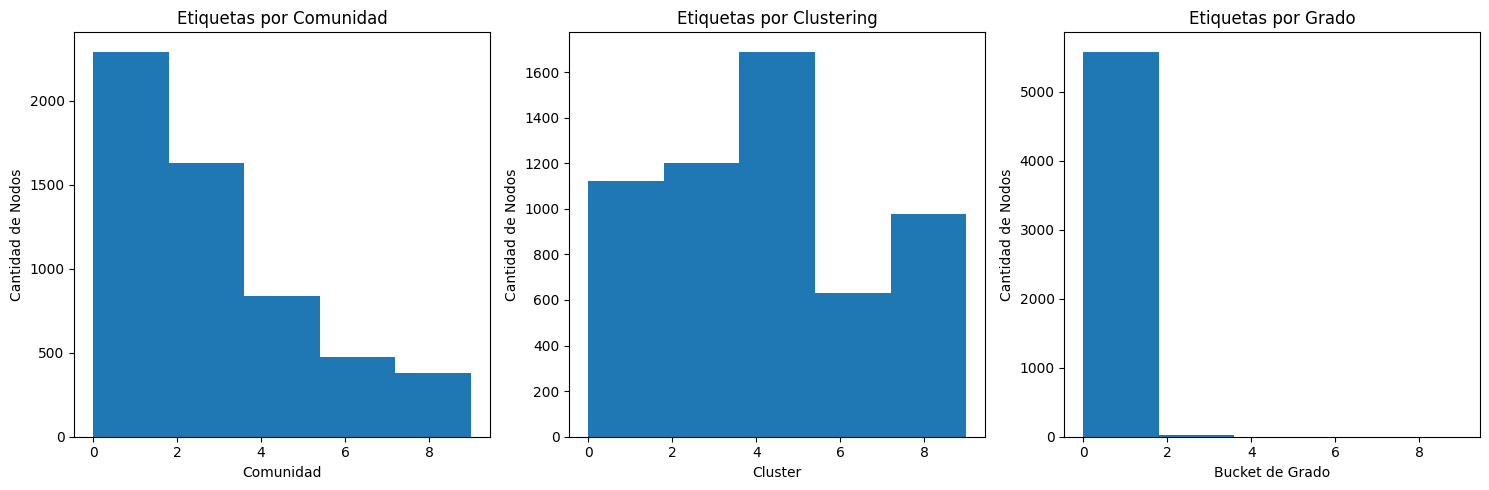

In [19]:
def create_synthetic_node_labels(embeddings=None, edge_index=None, num_nodes=None, method='clustering', n_clusters=10):
    print(f"Generando etiquetas sintéticas usando método: {method}")

    if method == 'clustering' and embeddings is not None:
        embeddings_np = embeddings.detach().cpu().numpy()
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings_np)
        return torch.tensor(labels, dtype=torch.long)

    elif method == 'community' and edge_index is not None:
        temp_data = torch.zeros(num_nodes).reshape(-1, 1)
        temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=edge_index)
        G = to_networkx(temp_data_obj, to_undirected=True)
        partition = community_louvain.best_partition(G)
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, community_id in partition.items():
            labels[node] = community_id % n_clusters

        return labels

    elif method == 'degree' and edge_index is not None:
        G = to_networkx(torch_geometric.data.Data(edge_index=edge_index), to_undirected=True)
        degrees = dict(G.degree())
        max_degree = max(degrees.values())
        labels = torch.zeros(num_nodes, dtype=torch.long)
        for node, degree in degrees.items():
            bucket = min(int((degree / max_degree) * n_clusters), n_clusters - 1)
            labels[node] = bucket

        return labels

    else:
        print("Usando método aleatorio para generar etiquetas")
        return torch.randint(0, n_clusters, (num_nodes,))

print("Generando etiquetas para los nodos con tres métodos diferentes...")

community_labels = create_synthetic_node_labels(
    edge_index=data_f.edge_index,
    num_nodes=data_f.num_nodes,
    method='community',
    n_clusters=10
)

clustering_labels = create_synthetic_node_labels(
    embeddings=node_embeddings,
    method='clustering',
    n_clusters=10
)

degree_labels = create_synthetic_node_labels(
    edge_index=data_f.edge_index,
    num_nodes=data_f.num_nodes,
    method='degree',
    n_clusters=10
)

node_labels = community_labels

print("Etiquetas generadas con éxito.")
print(f"Número de nodos: {data_f.num_nodes}")
print(f"Número de aristas: {data_f.edge_index.shape[1] // 2}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(community_labels.numpy(), bins=5)
plt.title('Etiquetas por Comunidad')
plt.xlabel('Comunidad')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 2)
plt.hist(clustering_labels.numpy(), bins=5)
plt.title('Etiquetas por Clustering')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Nodos')

plt.subplot(1, 3, 3)
plt.hist(degree_labels.numpy(), bins=5)
plt.title('Etiquetas por Grado')
plt.xlabel('Bucket de Grado')
plt.ylabel('Cantidad de Nodos')

plt.tight_layout()
plt.show()

# **PREPARACIÓN DE DATOS**

In [20]:
from torch_geometric.utils import negative_sampling

In [21]:
filtered_labels = data_f.y
data_f.x = node_embeddings.detach().clone()
data_f.x = torch.nan_to_num(data_f.x, nan=0.0, posinf=1.0, neginf=-1.0)

num_nodes = data_f.num_nodes
train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)

# máscaras booleanas
data_f.train_mask = torch.zeros(data_f.num_nodes, dtype=torch.bool)
data_f.val_mask = torch.zeros(data_f.num_nodes, dtype=torch.bool)
data_f.test_mask = torch.zeros(data_f.num_nodes, dtype=torch.bool)

data_f.train_mask[:train_size] = True
data_f.val_mask[train_size:train_size + val_size] = True
data_f.test_mask[train_size + val_size:] = True

train_edge_index = data_f.edge_index

neg_edge_index = negative_sampling(
    edge_index=train_edge_index,
    num_nodes=data_f.num_nodes,
    num_neg_samples=train_edge_index.shape[1]  # Mismo número que edges positivos
)

data_f.neg_edge_index_train = neg_edge_index

print(f"Distribución de nodos:")
print(f"  Entrenamiento: {data_f.train_mask.sum().item()} nodos")
print(f"  Validación: {data_f.val_mask.sum().item()} nodos")
print(f"  Prueba: {data_f.test_mask.sum().item()} nodos")
print(f"Muestras negativas generadas para entrenamiento: {neg_edge_index.shape[1]}")

Distribución de nodos:
  Entrenamiento: 4496 nodos
  Validación: 562 nodos
  Prueba: 562 nodos
Muestras negativas generadas para entrenamiento: 326872


Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...


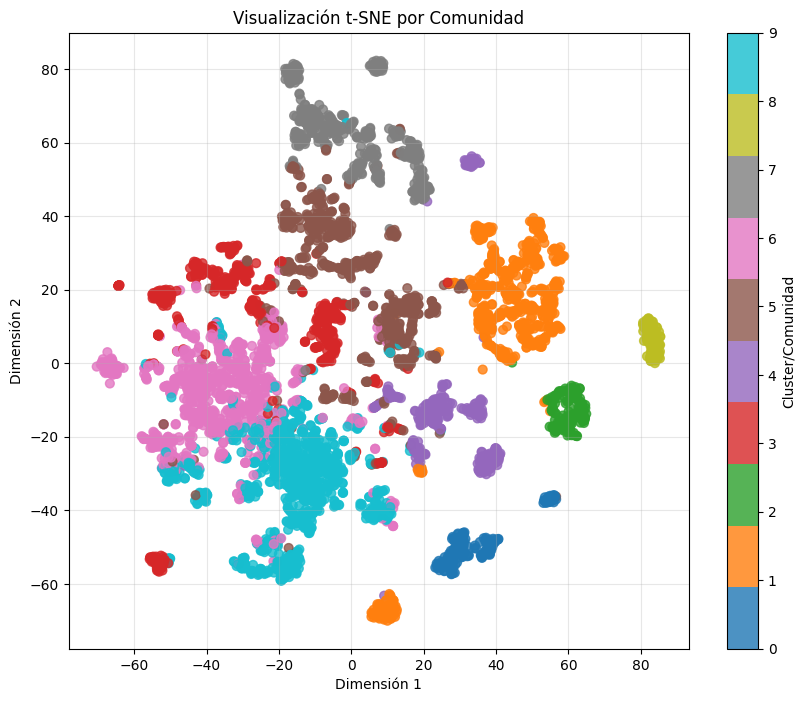

In [16]:
def visualize_embeddings_with_labels(embeddings, labels, title):
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings.detach().cpu().numpy())

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        c=labels.cpu().numpy(),
        cmap='tab10',
        alpha=0.8,
        s=40
    )
    plt.colorbar(scatter, label='Cluster/Comunidad')
    plt.title(title)
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')
    plt.grid(alpha=0.3)
    plt.show()

    return embeddings_2d

print("Aplicando t-SNE y visualizando embeddings con etiquetas por Comunidad...")
embeddings_2d_community = visualize_embeddings_with_labels(
    data_f.x,
    node_labels,
    'Visualización t-SNE por Comunidad'
)

def visualize_network(data, node_labels=None, layout='spring', title=None):
    print(f"Visualizando grafo con layout {layout}...")

    temp_data = torch.zeros(data.num_nodes).reshape(-1, 1)
    temp_data_obj = torch_geometric.data.Data(x=temp_data, edge_index=data.edge_index)
    G = to_networkx(temp_data_obj, to_undirected=True)

    if layout == 'spring':
        pos = nx.spring_layout(G, seed=42)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    else:
        pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 10))

    if node_labels is not None:
        node_colors = node_labels.cpu().numpy()
        nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                             node_size=50, alpha=0.8, cmap='tab10')
    else:
        nx.draw_networkx_nodes(G, pos, node_size=50, alpha=0.8)

    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

    if title:
        plt.title(title)
    else:
        plt.title(f'Visualización de Grafo con Layout {layout.capitalize()}')

    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G, pos

Visualizando grafo con layout spring...


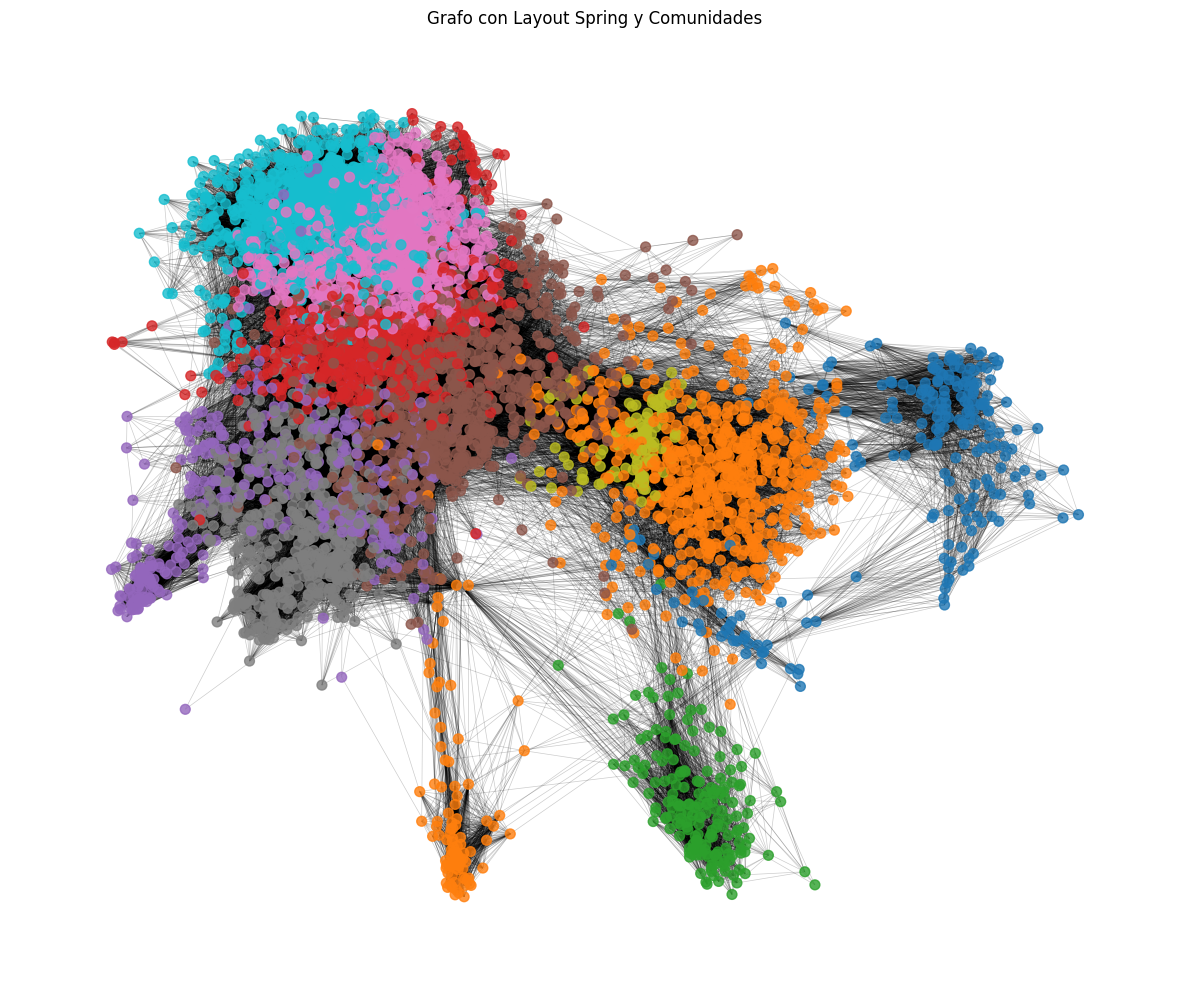

In [17]:
G_spring, pos_spring = visualize_network(
    data_f,
    node_labels=node_labels,
    layout='spring',
    title='Grafo con Layout Spring y Comunidades'
)

# **MATRIZ DE ADYACENCIA**

Forma de la matriz de adyacencia: torch.Size([5620, 5620])
Tipo de datos: torch.float32


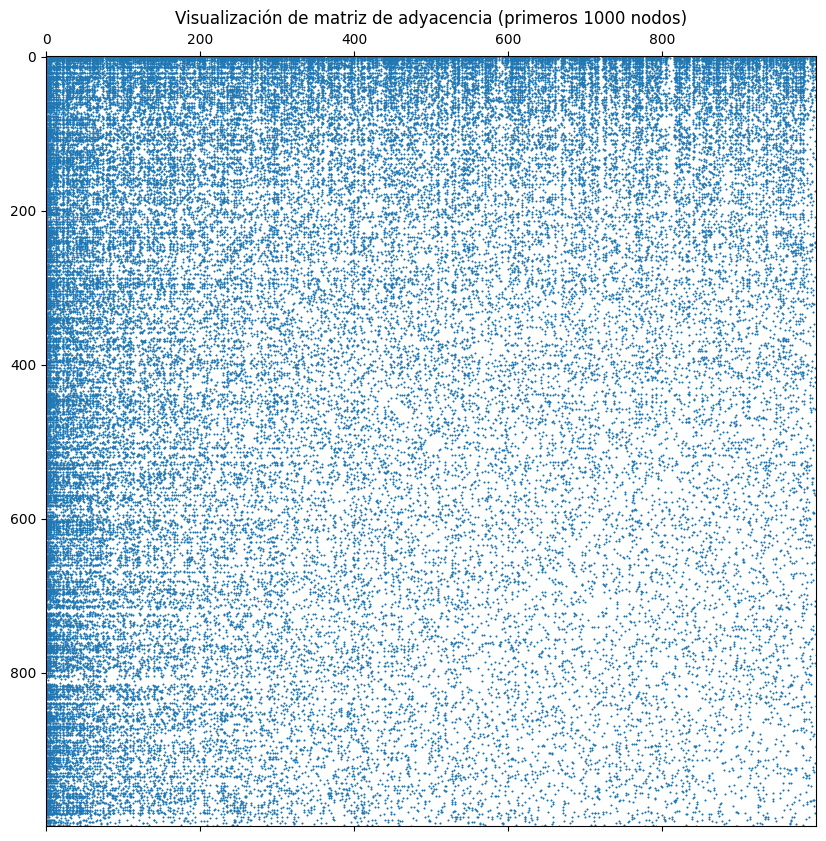

In [22]:
adj_matrix = to_dense_adj(data_f.edge_index)[0]
print(f"Forma de la matriz de adyacencia: {adj_matrix.shape}")
print(f"Tipo de datos: {adj_matrix.dtype}")

plt.figure(figsize=(10, 10))
plt.spy(adj_matrix[:1000, :1000], markersize=0.5)
plt.title("Visualización de matriz de adyacencia (primeros 1000 nodos)")
plt.show()

In [23]:
n_nodes = adj_matrix.shape[0]
n_possible_edges = n_nodes * (n_nodes - 1) / 2
n_actual_edges = (adj_matrix.sum() / 2).item()
density = n_actual_edges / n_possible_edges
print(f"Densidad de la matriz de adyacencia: {density:.6f}")
print(f"Número de enlaces: {n_actual_edges} de {n_possible_edges} posibles")

Densidad de la matriz de adyacencia: 0.010351
Número de enlaces: 163436.0 de 15789390.0 posibles


# **MODELOS DE CLASIFICACIÓN**

# MLP

[I 2025-05-23 01:14:34,004] A new study created in memory with name: no-name-6e2302b6-b6b1-42f2-ad07-170400e19d15


Iniciando búsqueda de hiperparámetros para MLP con Node2Vec embeddings...
Iniciando búsqueda de hiperparámetros con Optuna...
Número de trials: 50


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-23 01:14:35,528] Trial 0 finished with value: 0.6901467971530248 and parameters: {'hidden_channels': 128, 'num_layers': 2, 'dropout': 0.20919616423534187, 'lr': 0.00014936568554617635, 'weight_decay': 0.0029154431891537554}. Best is trial 0 with value: 0.6901467971530248.
[I 2025-05-23 01:14:35,836] Trial 1 finished with value: 0.18425266903914592 and parameters: {'hidden_channels': 512, 'num_layers': 4, 'dropout': 0.24863737747479334, 'lr': 0.0003511356313970409, 'weight_decay': 5.415244119402541e-06}. Best is trial 0 with value: 0.6901467971530248.
[I 2025-05-23 01:14:35,945] Trial 2 finished with value: 0.4538256227758007 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.19764570245642932, 'lr': 0.0007523742884534858, 'weight_decay': 2.9204338471814107e-05}. Best is trial 0 with value: 0.6901467971530248.
[I 2025-05-23 01:14:36,407] Trial 3 finished with value: 0.9199288256227758 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.1

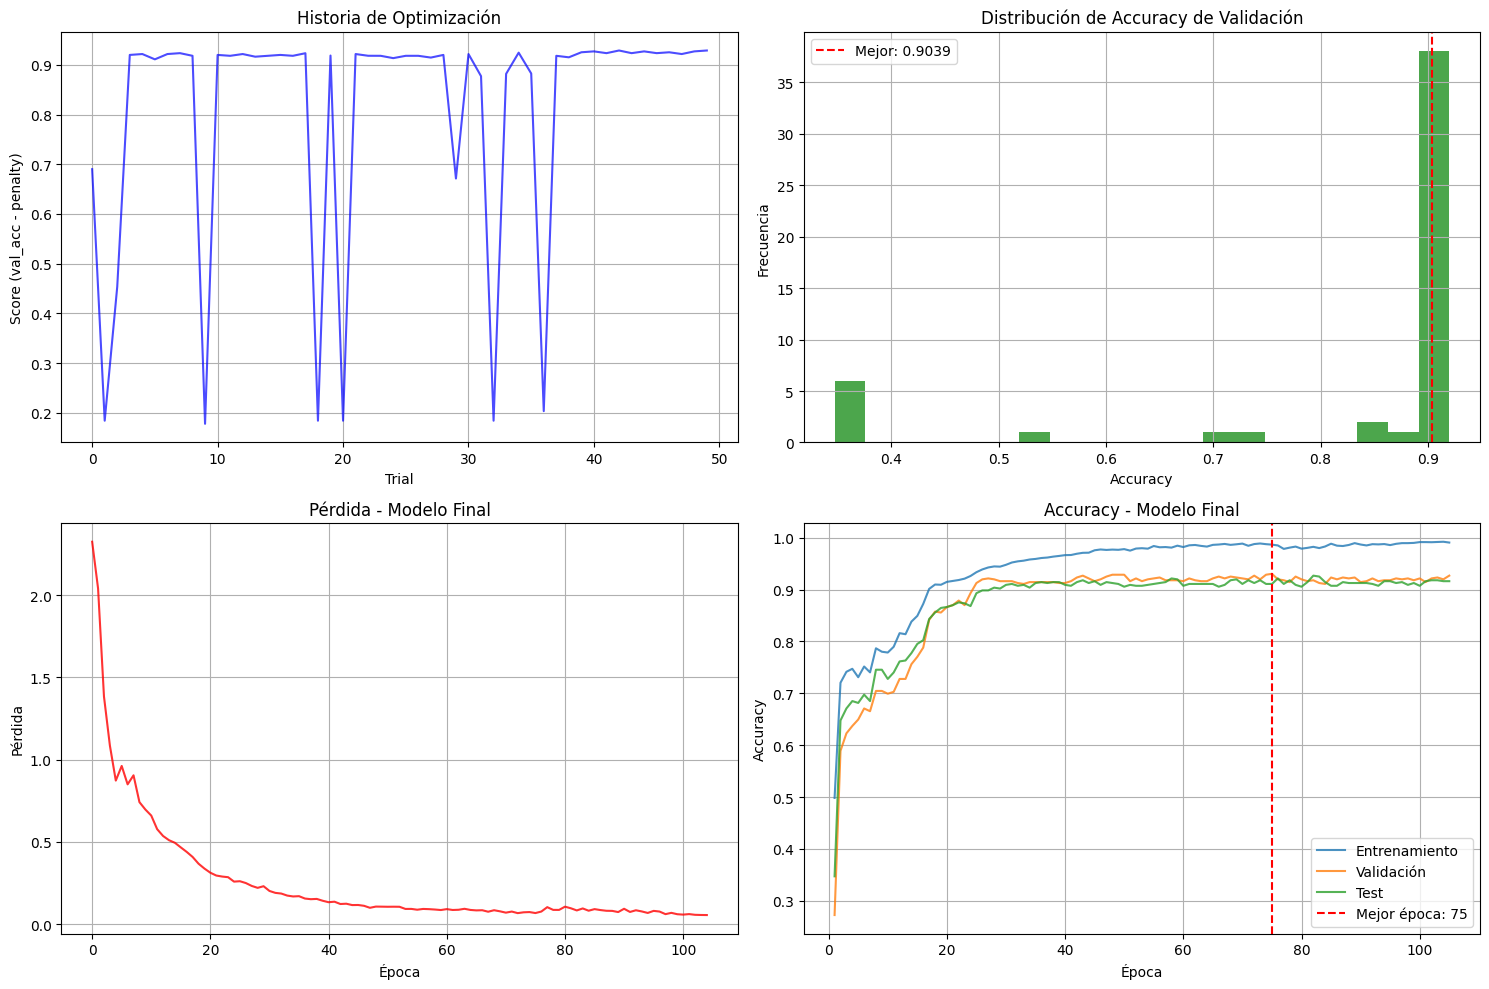

In [24]:
class MLP(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(MLP, self).__init__()
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.layers.append(torch.nn.Linear(hidden_channels, hidden_channels))
        self.layers.append(torch.nn.Linear(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.layers[-1](x)
        return F.log_softmax(x, dim=1)

def train_evaluate_mlp_single(node_embeddings, labels, train_mask, val_mask, test_mask,
                              hidden_channels=128, num_layers=2, dropout=0.5,
                              lr=0.01, weight_decay=5e-4, epochs=200,
                              early_stopping=True, patience=20, verbose=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    node_embeddings = node_embeddings.detach().clone()
    in_channels = node_embeddings.shape[1]
    out_channels = int(labels.max()) + 1

    x = node_embeddings.to(device)
    y = labels.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    model = MLP(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0
    best_test_acc = 0
    best_epoch = 0
    patience_counter = 0
    train_accs, val_accs, test_accs = [], [], []
    losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        out = model(x)
        loss = F.nll_loss(out[train_mask], y[train_mask])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x).argmax(dim=1)

            train_correct = pred[train_mask].eq(y[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)

            val_correct = pred[val_mask].eq(y[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)

            test_correct = pred[test_mask].eq(y[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if early_stopping and patience_counter >= patience:
                if verbose:
                    print(f"Early stopping en época {epoch}")
                break

        if verbose and (epoch % 50 == 0 or epoch == 1):
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    final_train_acc = train_accs[best_epoch-1] if best_epoch > 0 else train_accs[-1]
    overfitting_gap = final_train_acc - best_val_acc

    return {
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'best_epoch': best_epoch,
        'overfitting_gap': overfitting_gap,
        'final_train_acc': final_train_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

def objective(trial, node_embeddings, labels, train_mask, val_mask, test_mask):
    hidden_channels = trial.suggest_categorical('hidden_channels', [64, 128, 256, 512])
    num_layers = trial.suggest_int('num_layers', 2, 4)
    dropout = trial.suggest_float('dropout', 0.1, 0.8)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    results = train_evaluate_mlp_single(
        node_embeddings=node_embeddings,
        labels=labels,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=150,
        early_stopping=True,
        patience=15,
        verbose=False
    )

    val_acc = results['best_val_acc']
    overfitting_penalty = max(0, results['overfitting_gap'] - 0.05)
    score = val_acc - (overfitting_penalty * 0.5)

    trial.set_user_attr('test_acc', results['best_test_acc'])
    trial.set_user_attr('overfitting_gap', results['overfitting_gap'])
    trial.set_user_attr('best_epoch', results['best_epoch'])

    return score

def hyperparameter_search(node_embeddings, labels, train_mask, val_mask, test_mask,
                         n_trials=50, timeout=None):
    print("Iniciando búsqueda de hiperparámetros con Optuna...")
    print(f"Número de trials: {n_trials}")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)
    )

    study.optimize(
        lambda trial: objective(trial, node_embeddings, labels, train_mask, val_mask, test_mask),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    return study

def display_best_params(study):
    print("\n" + "="*60)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
    print("="*60)

    best_trial = study.best_trial
    print(f"Mejor score (val_acc - overfitting_penalty): {best_trial.value:.4f}")
    print(f"Accuracy de validación: {best_trial.user_attrs['test_acc']:.4f}")
    print(f"Accuracy de test: {best_trial.user_attrs['test_acc']:.4f}")
    print(f"Gap de sobreajuste: {best_trial.user_attrs['overfitting_gap']:.4f}")
    print(f"Mejor época: {best_trial.user_attrs['best_epoch']}")

    print("\nHiperparámetros:")
    for key, value in best_trial.params.items():
        print(f"  {key}: {value}")

    return best_trial.params

def train_final_model(node_embeddings, labels, train_mask, val_mask, test_mask, best_params):
    print("\n" + "="*60)
    print("ENTRENANDO MODELO FINAL")
    print("="*60)

    results = train_evaluate_mlp_single(
        node_embeddings=node_embeddings,
        labels=labels,
        train_mask=train_mask,
        val_mask=val_mask,
        test_mask=test_mask,
        hidden_channels=best_params['hidden_channels'],
        num_layers=best_params['num_layers'],
        dropout=best_params['dropout'],
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        epochs=300,
        early_stopping=True,
        patience=30,
        verbose=True
    )

    print(f"\nRESULTADOS FINALES:")
    print(f"Mejor accuracy de validación: {results['best_val_acc']:.4f}")
    print(f"Accuracy de test correspondiente: {results['best_test_acc']:.4f}")
    print(f"Gap de sobreajuste: {results['overfitting_gap']:.4f}")
    print(f"Mejor época: {results['best_epoch']}")

    return results

def plot_optimization_results(study, final_results):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    ax1 = axes[0, 0]
    values = [trial.value for trial in study.trials if trial.value is not None]
    ax1.plot(values, 'b-', alpha=0.7)
    ax1.set_title('Historia de Optimización')
    ax1.set_xlabel('Trial')
    ax1.set_ylabel('Score (val_acc - penalty)')
    ax1.grid(True)

    ax2 = axes[0, 1]
    val_accs = [trial.user_attrs.get('test_acc', 0) for trial in study.trials
                if trial.user_attrs.get('test_acc') is not None]
    ax2.hist(val_accs, bins=20, alpha=0.7, color='green')
    ax2.axvline(study.best_trial.user_attrs['test_acc'], color='red', linestyle='--',
                label=f"Mejor: {study.best_trial.user_attrs['test_acc']:.4f}")
    ax2.set_title('Distribución de Accuracy de Validación')
    ax2.set_xlabel('Accuracy')
    ax2.set_ylabel('Frecuencia')
    ax2.legend()
    ax2.grid(True)

    ax3 = axes[1, 0]
    ax3.plot(final_results['losses'], 'r-', alpha=0.8)
    ax3.set_title('Pérdida - Modelo Final')
    ax3.set_xlabel('Época')
    ax3.set_ylabel('Pérdida')
    ax3.grid(True)

    ax4 = axes[1, 1]
    epochs = range(1, len(final_results['train_accs']) + 1)
    ax4.plot(epochs, final_results['train_accs'], label='Entrenamiento', alpha=0.8)
    ax4.plot(epochs, final_results['val_accs'], label='Validación', alpha=0.8)
    ax4.plot(epochs, final_results['test_accs'], label='Test', alpha=0.8)
    ax4.axvline(final_results['best_epoch'], color='red', linestyle='--',
                label=f"Mejor época: {final_results['best_epoch']}")
    ax4.set_title('Accuracy - Modelo Final')
    ax4.set_xlabel('Época')
    ax4.set_ylabel('Accuracy')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

def plot_param_importance(study):
    try:
        fig = plot_param_importances(study)
        fig.show()
    except Exception as e:
        print(f"No se pudo generar gráfico de importancia: {e}")

print("Iniciando búsqueda de hiperparámetros para MLP con Node2Vec embeddings...")

data_f.x = data_f.x.detach().clone()

try:
    study = hyperparameter_search(
        node_embeddings=data_f.x,
        labels=filtered_labels,
        train_mask=data_f.train_mask,
        val_mask=data_f.val_mask,
        test_mask=data_f.test_mask,
        n_trials=50,
        timeout=1800
    )

    best_params = display_best_params(study)

    final_results = train_final_model(
        node_embeddings=data_f.x,
        labels=filtered_labels,
        train_mask=data_f.train_mask,
        val_mask=data_f.val_mask,
        test_mask=data_f.test_mask,
        best_params=best_params
    )

    plot_optimization_results(study, final_results)
    plot_param_importance(study)

except Exception as e:
    print(f"Error durante el proceso: {e}")
    import traceback
    traceback.print_exc()

# **GCN**

[I 2025-05-23 01:14:51,051] A new study created in memory with name: no-name-c741b51f-ac1a-4a3e-9fdf-def4bcf3cc35


Iniciando búsqueda de hiperparámetros para GCN...
Forma de la matriz de adyacencia: torch.Size([5620, 5620])
Tipo de datos: torch.float32
Iniciando búsqueda de hiperparámetros para GCN...
Número de trials: 50


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-23 01:14:53,554] Trial 0 finished with value: 0.6775800711743772 and parameters: {'hidden_channels': 128, 'num_layers': 2, 'dropout': 0.20919616423534187, 'lr': 0.00014936568554617635, 'weight_decay': 0.0029154431891537554}. Best is trial 0 with value: 0.6775800711743772.
[I 2025-05-23 01:14:55,286] Trial 1 finished with value: 0.32615658362989325 and parameters: {'hidden_channels': 512, 'num_layers': 4, 'dropout': 0.24863737747479334, 'lr': 0.0003511356313970409, 'weight_decay': 5.415244119402541e-06}. Best is trial 0 with value: 0.6775800711743772.
[I 2025-05-23 01:14:58,823] Trial 2 finished with value: 0.8149466192170819 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.19764570245642932, 'lr': 0.0007523742884534858, 'weight_decay': 2.9204338471814107e-05}. Best is trial 2 with value: 0.8149466192170819.
[I 2025-05-23 01:15:01,526] Trial 3 finished with value: 0.9199288256227758 and parameters: {'hidden_channels': 128, 'num_layers': 3, 'dropout': 0.1

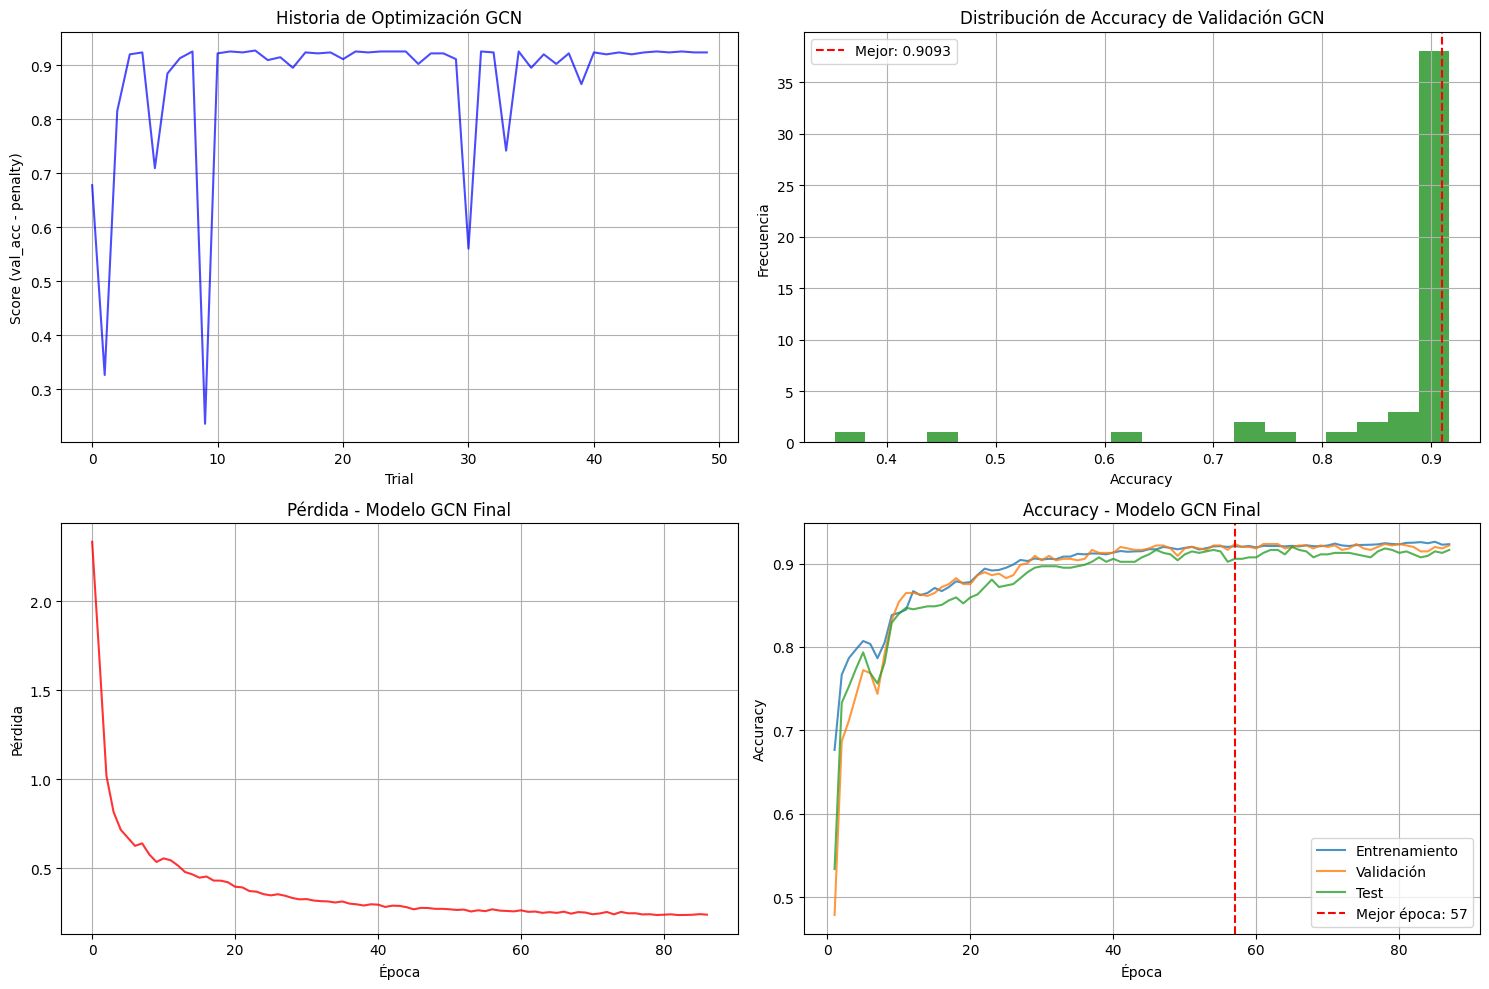


Generando matriz de confusión para el conjunto de test...


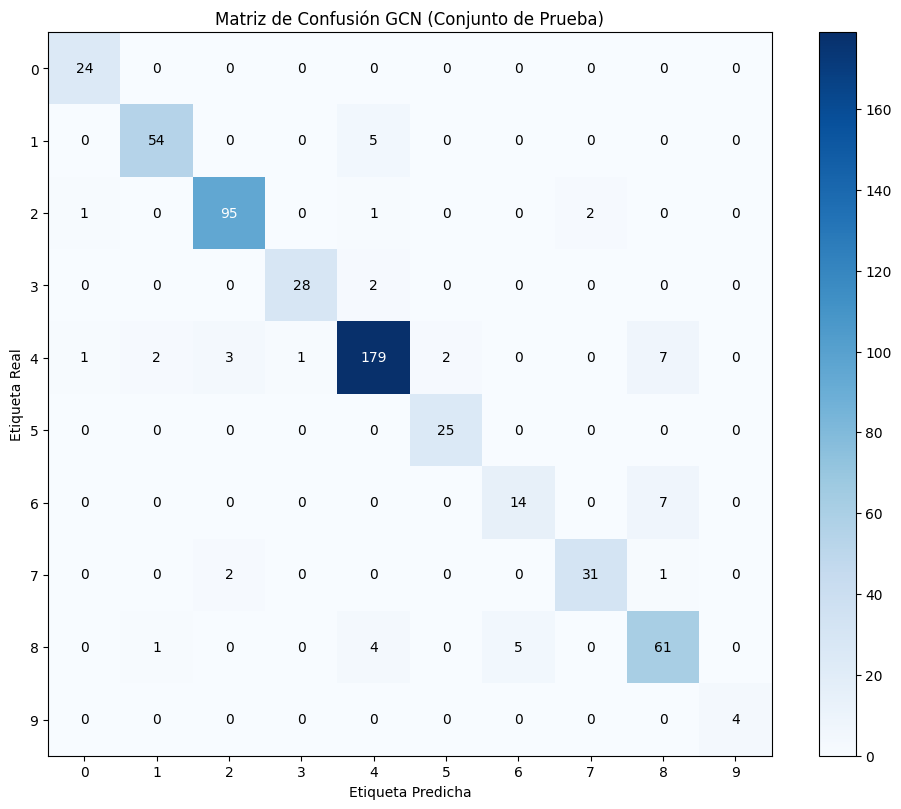

In [25]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super(GCN, self).__init__()
        self.lins = torch.nn.ModuleList()
        self.lins.append(torch.nn.Linear(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.lins.append(torch.nn.Linear(hidden_channels, hidden_channels))
        self.lins.append(torch.nn.Linear(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, adj_matrix):
        degree = adj_matrix.sum(dim=1)
        degree = torch.clamp(degree, min=1.0)
        deg_inv_sqrt = degree.pow(-0.5)
        norm_adj = deg_inv_sqrt.unsqueeze(1) * adj_matrix * deg_inv_sqrt.unsqueeze(0)

        for i, lin in enumerate(self.lins[:-1]):
            x = norm_adj @ x
            x = lin(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = norm_adj @ x
        x = self.lins[-1](x)
        return F.log_softmax(x, dim=1)

def train_evaluate_gcn_single(data, adj_matrix, labels, hidden_channels=128,
                              num_layers=2, dropout=0.5, lr=0.01, weight_decay=5e-4,
                              epochs=200, early_stopping=True, patience=20, verbose=False):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    in_channels = data.x.shape[1]
    out_channels = int(labels.max()) + 1

    x = data.x.to(device)
    adj = adj_matrix.to(device)
    y = labels.to(device)
    train_mask = data.train_mask.to(device)
    val_mask = data.val_mask.to(device)
    test_mask = data.test_mask.to(device)

    model = GCN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0
    best_test_acc = 0
    best_epoch = 0
    patience_counter = 0
    train_accs, val_accs, test_accs = [], [], []
    losses = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(x, adj)
        loss = F.nll_loss(out[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            pred = model(x, adj).argmax(dim=1)

            train_correct = pred[train_mask].eq(y[train_mask]).sum().item()
            train_acc = train_correct / train_mask.sum().item()
            train_accs.append(train_acc)

            val_correct = pred[val_mask].eq(y[val_mask]).sum().item()
            val_acc = val_correct / val_mask.sum().item()
            val_accs.append(val_acc)

            test_correct = pred[test_mask].eq(y[test_mask]).sum().item()
            test_acc = test_correct / test_mask.sum().item()
            test_accs.append(test_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_test_acc = test_acc
                best_epoch = epoch
                patience_counter = 0
            else:
                patience_counter += 1

            if early_stopping and patience_counter >= patience:
                if verbose:
                    print(f"Early stopping en época {epoch}")
                break

        if verbose and (epoch % 50 == 0 or epoch == 1):
            print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

    final_train_acc = train_accs[best_epoch-1] if best_epoch > 0 else train_accs[-1]
    overfitting_gap = final_train_acc - best_val_acc

    return {
        'model': model,
        'best_val_acc': best_val_acc,
        'best_test_acc': best_test_acc,
        'best_epoch': best_epoch,
        'overfitting_gap': overfitting_gap,
        'final_train_acc': final_train_acc,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'test_accs': test_accs,
        'losses': losses
    }

def objective_gcn(trial, data, adj_matrix, labels):
    hidden_channels = trial.suggest_categorical('hidden_channels', [64, 128, 256, 512])
    num_layers = trial.suggest_int('num_layers', 2, 4)
    dropout = trial.suggest_float('dropout', 0.1, 0.8)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    results = train_evaluate_gcn_single(
        data=data,
        adj_matrix=adj_matrix,
        labels=labels,
        hidden_channels=hidden_channels,
        num_layers=num_layers,
        dropout=dropout,
        lr=lr,
        weight_decay=weight_decay,
        epochs=150,
        early_stopping=True,
        patience=15,
        verbose=False
    )

    val_acc = results['best_val_acc']
    overfitting_penalty = max(0, results['overfitting_gap'] - 0.05)
    score = val_acc - (overfitting_penalty * 0.5)

    trial.set_user_attr('test_acc', results['best_test_acc'])
    trial.set_user_attr('overfitting_gap', results['overfitting_gap'])
    trial.set_user_attr('best_epoch', results['best_epoch'])

    return score

def hyperparameter_search_gcn(data, adj_matrix, labels, n_trials=50, timeout=None):
    print("Iniciando búsqueda de hiperparámetros para GCN...")
    print(f"Número de trials: {n_trials}")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=30)
    )

    study.optimize(
        lambda trial: objective_gcn(trial, data, adj_matrix, labels),
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True
    )

    return study

def display_best_params_gcn(study):
    print("\n" + "="*60)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA GCN")
    print("="*60)

    best_trial = study.best_trial
    print(f"Mejor score (val_acc - overfitting_penalty): {best_trial.value:.4f}")
    print(f"Accuracy de validación: {best_trial.user_attrs['test_acc']:.4f}")
    print(f"Accuracy de test: {best_trial.user_attrs['test_acc']:.4f}")
    print(f"Gap de sobreajuste: {best_trial.user_attrs['overfitting_gap']:.4f}")
    print(f"Mejor época: {best_trial.user_attrs['best_epoch']}")

    print("\nHiperparámetros:")
    for key, value in best_trial.params.items():
        print(f"  {key}: {value}")

    return best_trial.params

def train_final_gcn_model(data, adj_matrix, labels, best_params):
    print("\n" + "="*60)
    print("ENTRENANDO MODELO GCN FINAL")
    print("="*60)

    results = train_evaluate_gcn_single(
        data=data,
        adj_matrix=adj_matrix,
        labels=labels,
        hidden_channels=best_params['hidden_channels'],
        num_layers=best_params['num_layers'],
        dropout=best_params['dropout'],
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        epochs=300,
        early_stopping=True,
        patience=30,
        verbose=True
    )

    print(f"\nRESULTADOS FINALES GCN:")
    print(f"Mejor accuracy de validación: {results['best_val_acc']:.4f}")
    print(f"Accuracy de test correspondiente: {results['best_test_acc']:.4f}")
    print(f"Gap de sobreajuste: {results['overfitting_gap']:.4f}")
    print(f"Mejor época: {results['best_epoch']}")

    return results

def plot_confusion_matrix(model, data, adj_matrix, labels, mask, num_classes=10, title='Matriz de Confusión'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), adj_matrix.to(device))
        pred = out.argmax(dim=1)
        y_true = labels[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

        plt.figure(figsize=(10, 8))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(num_classes)
        plt.xticks(tick_marks, range(num_classes))
        plt.yticks(tick_marks, range(num_classes))

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, f"{cm[i, j]}",
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2. else "black")

        plt.tight_layout()
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Etiqueta Predicha')
        plt.show()
        return cm

def plot_gcn_optimization_results(study, final_results):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    ax1 = axes[0, 0]
    values = [trial.value for trial in study.trials if trial.value is not None]
    ax1.plot(values, 'b-', alpha=0.7)
    ax1.set_title('Historia de Optimización GCN')
    ax1.set_xlabel('Trial')
    ax1.set_ylabel('Score (val_acc - penalty)')
    ax1.grid(True)

    ax2 = axes[0, 1]
    val_accs = [trial.user_attrs.get('test_acc', 0) for trial in study.trials
                if trial.user_attrs.get('test_acc') is not None]
    ax2.hist(val_accs, bins=20, alpha=0.7, color='green')
    ax2.axvline(study.best_trial.user_attrs['test_acc'], color='red', linestyle='--',
                label=f"Mejor: {study.best_trial.user_attrs['test_acc']:.4f}")
    ax2.set_title('Distribución de Accuracy de Validación GCN')
    ax2.set_xlabel('Accuracy')
    ax2.set_ylabel('Frecuencia')
    ax2.legend()
    ax2.grid(True)

    ax3 = axes[1, 0]
    ax3.plot(final_results['losses'], 'r-', alpha=0.8)
    ax3.set_title('Pérdida - Modelo GCN Final')
    ax3.set_xlabel('Época')
    ax3.set_ylabel('Pérdida')
    ax3.grid(True)

    ax4 = axes[1, 1]
    epochs = range(1, len(final_results['train_accs']) + 1)
    ax4.plot(epochs, final_results['train_accs'], label='Entrenamiento', alpha=0.8)
    ax4.plot(epochs, final_results['val_accs'], label='Validación', alpha=0.8)
    ax4.plot(epochs, final_results['test_accs'], label='Test', alpha=0.8)
    ax4.axvline(final_results['best_epoch'], color='red', linestyle='--',
                label=f"Mejor época: {final_results['best_epoch']}")
    ax4.set_title('Accuracy - Modelo GCN Final')
    ax4.set_xlabel('Época')
    ax4.set_ylabel('Accuracy')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

def plot_param_importance_gcn(study):
    try:
        fig = plot_param_importances(study)
        fig.show()
    except Exception as e:
        print(f"No se pudo generar gráfico de importancia: {e}")

print("Iniciando búsqueda de hiperparámetros para GCN...")

adj_matrix = to_dense_adj(data_f.edge_index)[0]
print(f"Forma de la matriz de adyacencia: {adj_matrix.shape}")
print(f"Tipo de datos: {adj_matrix.dtype}")

try:
    study_gcn = hyperparameter_search_gcn(
        data=data_f,
        adj_matrix=adj_matrix,
        labels=filtered_labels,
        n_trials=50,
        timeout=1800
    )

    best_params_gcn = display_best_params_gcn(study_gcn)

    final_results_gcn = train_final_gcn_model(
        data=data_f,
        adj_matrix=adj_matrix,
        labels=filtered_labels,
        best_params=best_params_gcn
    )

    plot_gcn_optimization_results(study_gcn, final_results_gcn)
    plot_param_importance_gcn(study_gcn)

    print("\nGenerando matriz de confusión para el conjunto de test...")
    plot_confusion_matrix(
        final_results_gcn['model'],
        data_f,
        adj_matrix,
        filtered_labels,
        data_f.test_mask,
        num_classes=10,
        title='Matriz de Confusión GCN (Conjunto de Prueba)'
    )

except Exception as e:
    print(f"Error durante el proceso: {e}")
    import traceback
    traceback.print_exc()

# **GAT**

Iniciando búsqueda de hiperparámetros para GAT (optimizada para memoria)...
Características de entrada: 128
Número de aristas: 326872


[I 2025-05-23 01:16:43,176] A new study created in memory with name: no-name-db9bd20a-93f2-4728-a9ab-dc7ef7acd3ef


Iniciando búsqueda de hiperparámetros para GAT (optimizada para memoria)...
Número de trials: 30


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-05-23 01:16:44,957] Trial 0 finished with value: 0.26977313167259787 and parameters: {'heads': 8, 'hidden_channels': 16, 'num_layers': 2, 'dropout': 0.20919616423534187, 'lr': 0.00014936568554617635, 'weight_decay': 0.0029154431891537554}. Best is trial 0 with value: 0.26977313167259787.
[I 2025-05-23 01:16:52,913] Trial 1 finished with value: 0.7313167259786477 and parameters: {'heads': 8, 'hidden_channels': 32, 'num_layers': 3, 'dropout': 0.24863737747479334, 'lr': 0.0003511356313970409, 'weight_decay': 5.415244119402541e-06}. Best is trial 1 with value: 0.7313167259786477.
[I 2025-05-23 01:17:00,801] Trial 2 finished with value: 0.8291814946619217 and parameters: {'heads': 8, 'hidden_channels': 16, 'num_layers': 3, 'dropout': 0.19764570245642932, 'lr': 0.0007523742884534858, 'weight_decay': 2.9204338471814107e-05}. Best is trial 2 with value: 0.8291814946619217.
[I 2025-05-23 01:17:08,716] Trial 3 finished with value: 0.9252669039145908 and parameters: {'heads': 8, 'hidden_c

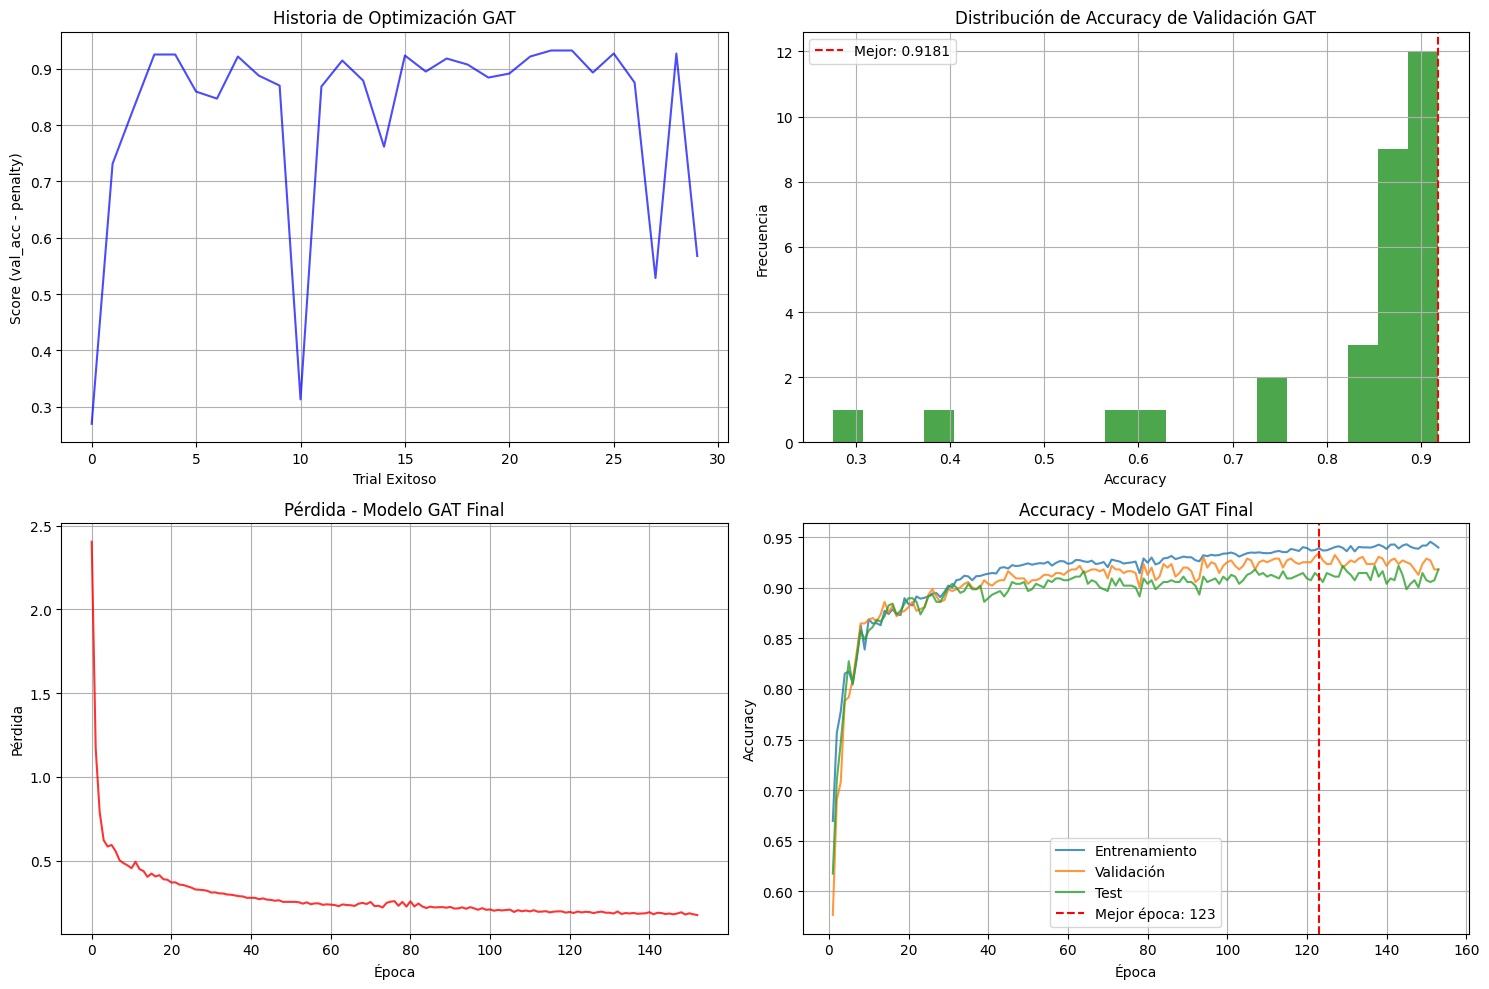


Generando matriz de confusión para el conjunto de test...


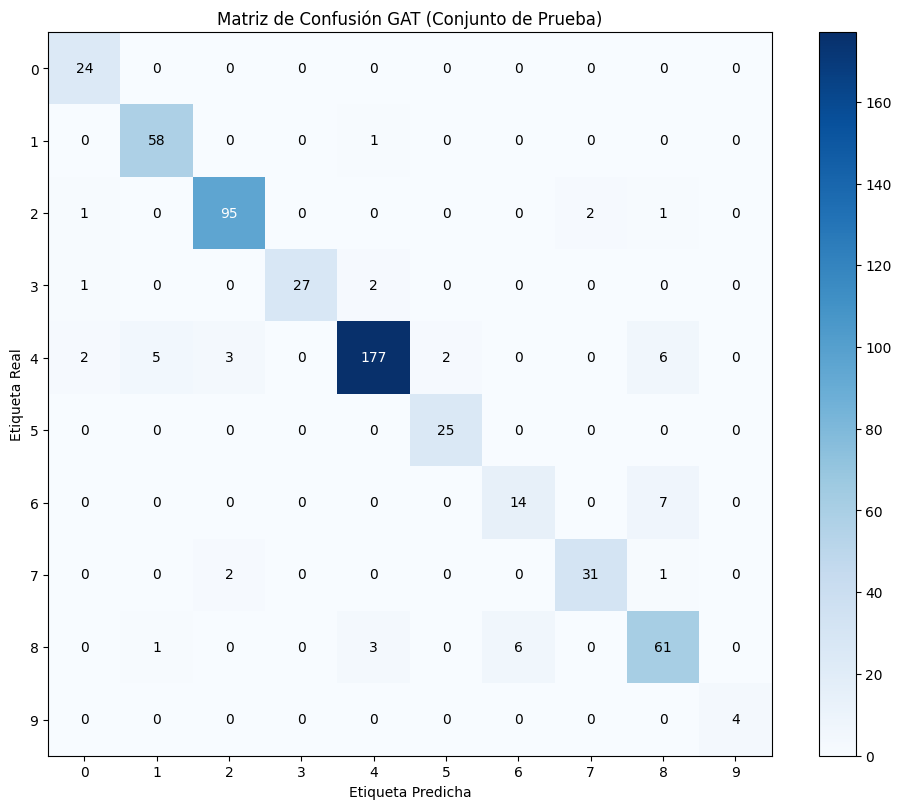

In [26]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=8, dropout=0.6):
        super(GAT, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))
        self.convs.append(GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout, concat=False))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

def clear_cuda_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

def memory_efficient_constraint(hidden_channels, num_layers, heads):
    memory_score = hidden_channels * heads * num_layers
    return memory_score < 2048

def train_evaluate_gat_single(data, edge_index, labels, hidden_channels=32,
                              num_layers=2, heads=8, dropout=0.6, lr=0.005,
                              weight_decay=5e-4, epochs=200, early_stopping=True,
                              patience=20, verbose=False):
    clear_cuda_memory()

    if not memory_efficient_constraint(hidden_channels, num_layers, heads):
        return {
            'model': None,
            'best_val_acc': 0.0,
            'best_test_acc': 0.0,
            'best_epoch': 0,
            'overfitting_gap': 1.0,
            'final_train_acc': 0.0,
            'train_accs': [0.0],
            'val_accs': [0.0],
            'test_accs': [0.0],
            'losses': [10.0]
        }

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    in_channels = data.x.shape[1]
    out_channels = int(labels.max()) + 1

    try:
        x = data.x.to(device)
        edge_idx = edge_index.to(device)
        y = labels.to(device)
        train_mask = data.train_mask.to(device)
        val_mask = data.val_mask.to(device)
        test_mask = data.test_mask.to(device)

        model = GAT(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=num_layers,
            heads=heads,
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        best_val_acc = 0
        best_test_acc = 0
        best_epoch = 0
        patience_counter = 0
        train_accs, val_accs, test_accs = [], [], []
        losses = []

        for epoch in range(1, epochs + 1):
            model.train()
            optimizer.zero_grad()
            out = model(x, edge_idx)
            loss = F.nll_loss(out[train_mask], y[train_mask])
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

            if epoch % 10 == 0:
                clear_cuda_memory()

            model.eval()
            with torch.no_grad():
                pred = model(x, edge_idx).argmax(dim=1)

                train_correct = pred[train_mask].eq(y[train_mask]).sum().item()
                train_acc = train_correct / train_mask.sum().item()
                train_accs.append(train_acc)

                val_correct = pred[val_mask].eq(y[val_mask]).sum().item()
                val_acc = val_correct / val_mask.sum().item()
                val_accs.append(val_acc)

                test_correct = pred[test_mask].eq(y[test_mask]).sum().item()
                test_acc = test_correct / test_mask.sum().item()
                test_accs.append(test_acc)

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_test_acc = test_acc
                    best_epoch = epoch
                    patience_counter = 0
                else:
                    patience_counter += 1

                if early_stopping and patience_counter >= patience:
                    if verbose:
                        print(f"Early stopping en época {epoch}")
                    break

            if verbose and (epoch % 50 == 0 or epoch == 1):
                print(f'Época {epoch:03d}: Loss={loss:.4f}, Train={train_acc:.4f}, Val={val_acc:.4f}, Test={test_acc:.4f}')

        final_train_acc = train_accs[best_epoch-1] if best_epoch > 0 else train_accs[-1]
        overfitting_gap = final_train_acc - best_val_acc

        result = {
            'model': model,
            'best_val_acc': best_val_acc,
            'best_test_acc': best_test_acc,
            'best_epoch': best_epoch,
            'overfitting_gap': overfitting_gap,
            'final_train_acc': final_train_acc,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'test_accs': test_accs,
            'losses': losses
        }

        clear_cuda_memory()
        return result

    except (RuntimeError, torch.cuda.OutOfMemoryError) as e:
        clear_cuda_memory()
        if verbose:
            print(f"Error de memoria: {e}")
        return {
            'model': None,
            'best_val_acc': 0.0,
            'best_test_acc': 0.0,
            'best_epoch': 0,
            'overfitting_gap': 1.0,
            'final_train_acc': 0.0,
            'train_accs': [0.0],
            'val_accs': [0.0],
            'test_accs': [0.0],
            'losses': [10.0]
        }

def objective_gat(trial, data, edge_index, labels):
    heads = trial.suggest_categorical('heads', [4, 8])
    hidden_channels = trial.suggest_categorical('hidden_channels', [16, 32])
    num_layers = trial.suggest_int('num_layers', 2, 3)

    if heads == 8 and hidden_channels == 32 and num_layers == 3:
        hidden_channels = 16

    dropout = trial.suggest_float('dropout', 0.1, 0.8)
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

    try:
        results = train_evaluate_gat_single(
            data=data,
            edge_index=edge_index,
            labels=labels,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            heads=heads,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            epochs=100,
            early_stopping=True,
            patience=15,
            verbose=False
        )

        val_acc = results['best_val_acc']
        overfitting_penalty = max(0, results['overfitting_gap'] - 0.05)
        score = val_acc - (overfitting_penalty * 0.5)

        trial.set_user_attr('test_acc', results['best_test_acc'])
        trial.set_user_attr('overfitting_gap', results['overfitting_gap'])
        trial.set_user_attr('best_epoch', results['best_epoch'])

        return score

    except Exception as e:
        print(f"Trial falló: {e}")
        return 0.0

def hyperparameter_search_gat(data, edge_index, labels, n_trials=50, timeout=None):
    print("Iniciando búsqueda de hiperparámetros para GAT (optimizada para memoria)...")
    print(f"Número de trials: {n_trials}")

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=20)
    )

    def objective_wrapper(trial):
        try:
            return objective_gat(trial, data, edge_index, labels)
        except Exception as e:
            print(f"Error en trial {trial.number}: {e}")
            return 0.0

    study.optimize(
        objective_wrapper,
        n_trials=n_trials,
        timeout=timeout,
        show_progress_bar=True,
        catch=(Exception,)
    )

    return study

def display_best_params_gat(study):
    print("\n" + "="*60)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA GAT")
    print("="*60)

    successful_trials = [t for t in study.trials if t.value is not None and t.value > 0]

    if not successful_trials:
        print("No se encontraron trials exitosos")
        return None

    best_trial = max(successful_trials, key=lambda t: t.value)
    print(f"Mejor score (val_acc - overfitting_penalty): {best_trial.value:.4f}")
    print(f"Accuracy de validación: {best_trial.user_attrs.get('test_acc', 'N/A')}")
    print(f"Accuracy de test: {best_trial.user_attrs.get('test_acc', 'N/A')}")
    print(f"Gap de sobreajuste: {best_trial.user_attrs.get('overfitting_gap', 'N/A')}")
    print(f"Mejor época: {best_trial.user_attrs.get('best_epoch', 'N/A')}")

    print("\nHiperparámetros:")
    for key, value in best_trial.params.items():
        print(f"  {key}: {value}")

    return best_trial.params

def train_final_gat_model(data, edge_index, labels, best_params):
    print("\n" + "="*60)
    print("ENTRENANDO MODELO GAT FINAL")
    print("="*60)

    results = train_evaluate_gat_single(
        data=data,
        edge_index=edge_index,
        labels=labels,
        hidden_channels=best_params['hidden_channels'],
        num_layers=best_params['num_layers'],
        heads=best_params['heads'],
        dropout=best_params['dropout'],
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        epochs=200,
        early_stopping=True,
        patience=30,
        verbose=True
    )

    print(f"\nRESULTADOS FINALES GAT:")
    print(f"Mejor accuracy de validación: {results['best_val_acc']:.4f}")
    print(f"Accuracy de test correspondiente: {results['best_test_acc']:.4f}")
    print(f"Gap de sobreajuste: {results['overfitting_gap']:.4f}")
    print(f"Mejor época: {results['best_epoch']}")

    return results

def plot_confusion_matrix_gat(model, data, edge_index, labels, mask, num_classes=10, title='Matriz de Confusión'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    with torch.no_grad():
        out = model(data.x.to(device), edge_index.to(device))
        pred = out.argmax(dim=1)
        y_true = labels[mask].cpu().numpy()
        y_pred = pred[mask].cpu().numpy()

        cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

        plt.figure(figsize=(10, 8))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(num_classes)
        plt.xticks(tick_marks, range(num_classes))
        plt.yticks(tick_marks, range(num_classes))

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, f"{cm[i, j]}",
                        ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2. else "black")

        plt.tight_layout()
        plt.ylabel('Etiqueta Real')
        plt.xlabel('Etiqueta Predicha')
        plt.show()
        return cm

def plot_gat_optimization_results(study, final_results):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    successful_trials = [t for t in study.trials if t.value is not None and t.value > 0]

    ax1 = axes[0, 0]
    values = [trial.value for trial in successful_trials]
    if values:
        ax1.plot(values, 'b-', alpha=0.7)
        ax1.set_title('Historia de Optimización GAT')
        ax1.set_xlabel('Trial Exitoso')
        ax1.set_ylabel('Score (val_acc - penalty)')
        ax1.grid(True)
    else:
        ax1.text(0.5, 0.5, 'No hay trials exitosos', ha='center', va='center', transform=ax1.transAxes)

    ax2 = axes[0, 1]
    val_accs = [trial.user_attrs.get('test_acc', 0) for trial in successful_trials
                if trial.user_attrs.get('test_acc') is not None and trial.user_attrs.get('test_acc') > 0]
    if val_accs:
        ax2.hist(val_accs, bins=min(20, len(val_accs)), alpha=0.7, color='green')
        best_acc = max(val_accs)
        ax2.axvline(best_acc, color='red', linestyle='--',
                    label=f"Mejor: {best_acc:.4f}")
        ax2.set_title('Distribución de Accuracy de Validación GAT')
        ax2.set_xlabel('Accuracy')
        ax2.set_ylabel('Frecuencia')
        ax2.legend()
        ax2.grid(True)
    else:
        ax2.text(0.5, 0.5, 'No hay datos de accuracy', ha='center', va='center', transform=ax2.transAxes)

    ax3 = axes[1, 0]
    if final_results and len(final_results['losses']) > 1:
        ax3.plot(final_results['losses'], 'r-', alpha=0.8)
        ax3.set_title('Pérdida - Modelo GAT Final')
        ax3.set_xlabel('Época')
        ax3.set_ylabel('Pérdida')
        ax3.grid(True)
    else:
        ax3.text(0.5, 0.5, 'No hay datos de pérdida', ha='center', va='center', transform=ax3.transAxes)

    ax4 = axes[1, 1]
    if final_results and len(final_results['train_accs']) > 1:
        epochs = range(1, len(final_results['train_accs']) + 1)
        ax4.plot(epochs, final_results['train_accs'], label='Entrenamiento', alpha=0.8)
        ax4.plot(epochs, final_results['val_accs'], label='Validación', alpha=0.8)
        ax4.plot(epochs, final_results['test_accs'], label='Test', alpha=0.8)
        ax4.axvline(final_results['best_epoch'], color='red', linestyle='--',
                    label=f"Mejor época: {final_results['best_epoch']}")
        ax4.set_title('Accuracy - Modelo GAT Final')
        ax4.set_xlabel('Época')
        ax4.set_ylabel('Accuracy')
        ax4.legend()
        ax4.grid(True)
    else:
        ax4.text(0.5, 0.5, 'No hay datos de accuracy', ha='center', va='center', transform=ax4.transAxes)

    plt.tight_layout()
    plt.show()

def plot_param_importance_gat(study):
    try:
        successful_trials = [t for t in study.trials if t.value is not None and t.value > 0]
        if len(successful_trials) > 5:
            fig = plot_param_importances(study)
            fig.show()
        else:
            print("Insuficientes trials exitosos para análisis de importancia")
    except Exception as e:
        print(f"No se pudo generar gráfico de importancia: {e}")

print("Iniciando búsqueda de hiperparámetros para GAT (optimizada para memoria)...")
print(f"Características de entrada: {data_f.x.shape[1]}")
print(f"Número de aristas: {data_f.edge_index.shape[1]}")

clear_cuda_memory()

try:
    study_gat = hyperparameter_search_gat(
        data=data_f,
        edge_index=data_f.edge_index,
        labels=filtered_labels,
        n_trials=30,
        timeout=1800
    )

    best_params_gat = display_best_params_gat(study_gat)

    if best_params_gat is not None:
        final_results_gat = train_final_gat_model(
            data=data_f,
            edge_index=data_f.edge_index,
            labels=filtered_labels,
            best_params=best_params_gat
        )

        plot_gat_optimization_results(study_gat, final_results_gat)
        plot_param_importance_gat(study_gat)

        if final_results_gat['model'] is not None:
            print("\nGenerando matriz de confusión para el conjunto de test...")
            plot_confusion_matrix_gat(
                final_results_gat['model'],
                data_f,
                data_f.edge_index,
                filtered_labels,
                data_f.test_mask,
                num_classes=10,
                title='Matriz de Confusión GAT (Conjunto de Prueba)'
            )

    else:
        print("No se pudieron encontrar hiperparámetros válidos")

except Exception as e:
    print(f"Error durante el proceso: {e}")
    import traceback
    traceback.print_exc()
finally:
    clear_cuda_memory()

# **COMPARATIVA DE RENDIMIENTOS**

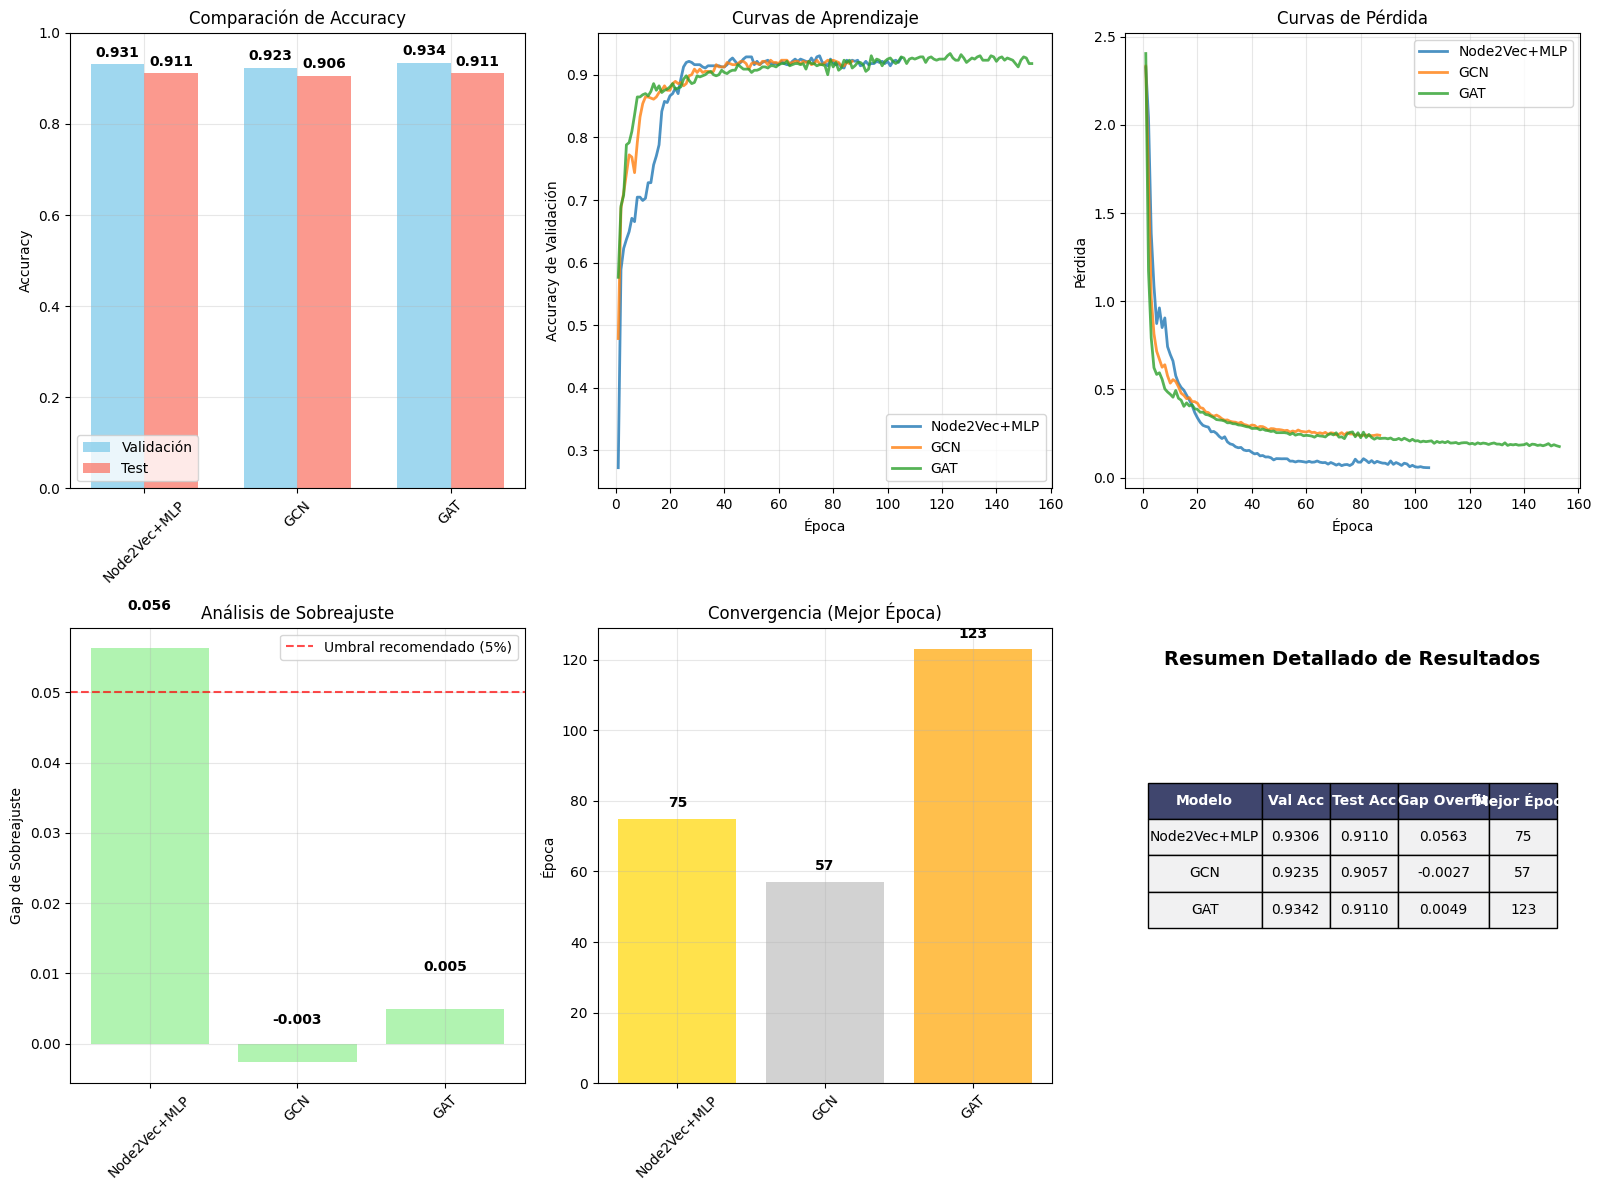


ANÁLISIS COMPARATIVO DE MODELOS

Mejor modelo por Test Accuracy:
  Node2Vec+MLP: 0.9110

Mejor modelo por Validation Accuracy:
  GAT: 0.9342

Menor sobreajuste:
  GCN: -0.0027

Convergencia más rápida:
  GCN: 57 épocas

Ranking general por Test Accuracy:
  1. Node2Vec+MLP: 0.9110
  2. GAT: 0.9110
  3. GCN: 0.9057

Análisis de sobreajuste:
  Node2Vec+MLP: 0.0563 (Bueno)
  GCN: -0.0027 (Excelente)
  GAT: 0.0049 (Excelente)


DataFrame de Resultados:
      Modelo  Validation_Accuracy  Test_Accuracy  Overfitting_Gap  Best_Epoch  Ranking
Node2Vec+MLP             0.930605       0.911032         0.056272          75        1
         GAT             0.934164       0.911032         0.004893         123        2
         GCN             0.923488       0.905694        -0.002669          57        3


,Modelo,Validation_Accuracy,Test_Accuracy,Overfitting_Gap,Best_Epoch,Ranking
0,Node2Vec+MLP,0.930605,0.911032,0.056272,75,1
1,GAT,0.934164,0.911032,0.004893,123,2
2,GCN,0.923488,0.905694,-0.002669,57,3


In [27]:
def compare_all_methods(node2vec_mlp_results, gcn_results, gat_results):
    plt.figure(figsize=(16, 12))

    models = ['Node2Vec+MLP', 'GCN', 'GAT']
    val_accs = [
        node2vec_mlp_results['best_val_acc'],
        gcn_results['best_val_acc'],
        gat_results['best_val_acc']
    ]
    test_accs = [
        node2vec_mlp_results['best_test_acc'],
        gcn_results['best_test_acc'],
        gat_results['best_test_acc']
    ]

    overfitting_gaps = [
        node2vec_mlp_results['overfitting_gap'],
        gcn_results['overfitting_gap'],
        gat_results['overfitting_gap']
    ]

    plt.subplot(2, 3, 1)
    x = range(len(models))
    width = 0.35

    bars1 = plt.bar([i - width/2 for i in x], val_accs, width, label='Validación', color='skyblue', alpha=0.8)
    bars2 = plt.bar([i + width/2 for i in x], test_accs, width, label='Test', color='salmon', alpha=0.8)

    for i, v in enumerate(val_accs):
        plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    for i, v in enumerate(test_accs):
        plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.ylabel('Accuracy')
    plt.title('Comparación de Accuracy')
    plt.xticks(x, models, rotation=45)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 2)
    max_epochs = max(len(node2vec_mlp_results['val_accs']),
                     len(gcn_results['val_accs']),
                     len(gat_results['val_accs']))

    epochs_mlp = range(1, len(node2vec_mlp_results['val_accs']) + 1)
    epochs_gcn = range(1, len(gcn_results['val_accs']) + 1)
    epochs_gat = range(1, len(gat_results['val_accs']) + 1)

    plt.plot(epochs_mlp, node2vec_mlp_results['val_accs'], label='Node2Vec+MLP', linewidth=2, alpha=0.8)
    plt.plot(epochs_gcn, gcn_results['val_accs'], label='GCN', linewidth=2, alpha=0.8)
    plt.plot(epochs_gat, gat_results['val_accs'], label='GAT', linewidth=2, alpha=0.8)

    plt.xlabel('Época')
    plt.ylabel('Accuracy de Validación')
    plt.title('Curvas de Aprendizaje')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 3)
    plt.plot(epochs_mlp, node2vec_mlp_results['losses'], label='Node2Vec+MLP', linewidth=2, alpha=0.8)
    plt.plot(epochs_gcn, gcn_results['losses'], label='GCN', linewidth=2, alpha=0.8)
    plt.plot(epochs_gat, gat_results['losses'], label='GAT', linewidth=2, alpha=0.8)

    plt.xlabel('Época')
    plt.ylabel('Pérdida')
    plt.title('Curvas de Pérdida')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 4)
    colors = ['lightcoral' if gap > 0.1 else 'lightgreen' for gap in overfitting_gaps]
    bars = plt.bar(models, overfitting_gaps, color=colors, alpha=0.7)

    for i, v in enumerate(overfitting_gaps):
        plt.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

    plt.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Umbral recomendado (5%)')
    plt.ylabel('Gap de Sobreajuste')
    plt.title('Análisis de Sobreajuste')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    best_epochs = [
        node2vec_mlp_results['best_epoch'],
        gcn_results['best_epoch'],
        gat_results['best_epoch']
    ]

    bars = plt.bar(models, best_epochs, color=['gold', 'silver', 'orange'], alpha=0.7)

    for i, v in enumerate(best_epochs):
        plt.text(i, v + max(best_epochs)*0.02, f'{v}', ha='center', va='bottom', fontweight='bold')

    plt.ylabel('Época')
    plt.title('Convergencia (Mejor Época)')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    plt.axis('off')

    table_data = [
        ['Modelo', 'Val Acc', 'Test Acc', 'Gap Overfit', 'Mejor Época'],
        ['Node2Vec+MLP', f"{val_accs[0]:.4f}", f"{test_accs[0]:.4f}", f"{overfitting_gaps[0]:.4f}", f"{best_epochs[0]}"],
        ['GCN', f"{val_accs[1]:.4f}", f"{test_accs[1]:.4f}", f"{overfitting_gaps[1]:.4f}", f"{best_epochs[1]}"],
        ['GAT', f"{val_accs[2]:.4f}", f"{test_accs[2]:.4f}", f"{overfitting_gaps[2]:.4f}", f"{best_epochs[2]}"]
    ]

    table = plt.table(cellText=table_data, loc='center', cellLoc='center',
                     colWidths=[0.25, 0.15, 0.15, 0.2, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    for i in range(len(table_data)):
        for j in range(len(table_data[0])):
            if i == 0:
                table[(i, j)].set_facecolor('#40466e')
                table[(i, j)].set_text_props(weight='bold', color='white')
            else:
                table[(i, j)].set_facecolor('#f1f1f2')

    plt.title('Resumen Detallado de Resultados', y=0.9, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    models_performance = {
        'Node2Vec+MLP': {
            'test_acc': test_accs[0],
            'val_acc': val_accs[0],
            'overfitting': overfitting_gaps[0],
            'convergence': best_epochs[0]
        },
        'GCN': {
            'test_acc': test_accs[1],
            'val_acc': val_accs[1],
            'overfitting': overfitting_gaps[1],
            'convergence': best_epochs[1]
        },
        'GAT': {
            'test_acc': test_accs[2],
            'val_acc': val_accs[2],
            'overfitting': overfitting_gaps[2],
            'convergence': best_epochs[2]
        }
    }

    best_by_test_acc = max(models_performance.items(), key=lambda x: x[1]['test_acc'])
    best_by_val_acc = max(models_performance.items(), key=lambda x: x[1]['val_acc'])
    least_overfitting = min(models_performance.items(), key=lambda x: x[1]['overfitting'])
    fastest_convergence = min(models_performance.items(), key=lambda x: x[1]['convergence'])

    print("\n" + "="*70)
    print("ANÁLISIS COMPARATIVO DE MODELOS")
    print("="*70)

    print(f"\nMejor modelo por Test Accuracy:")
    print(f"  {best_by_test_acc[0]}: {best_by_test_acc[1]['test_acc']:.4f}")

    print(f"\nMejor modelo por Validation Accuracy:")
    print(f"  {best_by_val_acc[0]}: {best_by_val_acc[1]['val_acc']:.4f}")

    print(f"\nMenor sobreajuste:")
    print(f"  {least_overfitting[0]}: {least_overfitting[1]['overfitting']:.4f}")

    print(f"\nConvergencia más rápida:")
    print(f"  {fastest_convergence[0]}: {fastest_convergence[1]['convergence']} épocas")

    print(f"\nRanking general por Test Accuracy:")
    sorted_models = sorted(models_performance.items(), key=lambda x: x[1]['test_acc'], reverse=True)
    for i, (model, metrics) in enumerate(sorted_models, 1):
        print(f"  {i}. {model}: {metrics['test_acc']:.4f}")

    overfitting_analysis = []
    for model, metrics in models_performance.items():
        if metrics['overfitting'] <= 0.05:
            status = "Excelente"
        elif metrics['overfitting'] <= 0.10:
            status = "Bueno"
        elif metrics['overfitting'] <= 0.15:
            status = "Aceptable"
        else:
            status = "Problemático"
        overfitting_analysis.append((model, metrics['overfitting'], status))

    print(f"\nAnálisis de sobreajuste:")
    for model, gap, status in overfitting_analysis:
        print(f"  {model}: {gap:.4f} ({status})")

    print("\n" + "="*70)

    return {
        'performance_summary': models_performance,
        'best_model': best_by_test_acc,
        'rankings': sorted_models
    }

def create_performance_dataframe(node2vec_mlp_results, gcn_results, gat_results):
    data = {
        'Modelo': ['Node2Vec+MLP', 'GCN', 'GAT'],
        'Validation_Accuracy': [
            node2vec_mlp_results['best_val_acc'],
            gcn_results['best_val_acc'],
            gat_results['best_val_acc']
        ],
        'Test_Accuracy': [
            node2vec_mlp_results['best_test_acc'],
            gcn_results['best_test_acc'],
            gat_results['best_test_acc']
        ],
        'Overfitting_Gap': [
            node2vec_mlp_results['overfitting_gap'],
            gcn_results['overfitting_gap'],
            gat_results['overfitting_gap']
        ],
        'Best_Epoch': [
            node2vec_mlp_results['best_epoch'],
            gcn_results['best_epoch'],
            gat_results['best_epoch']
        ]
    }

    df = pd.DataFrame(data)
    df = df.sort_values('Test_Accuracy', ascending=False).reset_index(drop=True)
    df['Ranking'] = range(1, len(df) + 1)

    print("\nDataFrame de Resultados:")
    print(df.to_string(index=False))

    return df

compare_all_methods(final_results, final_results_gcn, final_results_gat)
create_performance_dataframe(final_results, final_results_gcn, final_results_gat)

# **MODELOS DE CLASIFICACIÓN POR PRODUCTO**

In [31]:
def create_link_prediction_data_simple(edge_index, num_nodes, neg_ratio=1.0):
    edge_list = edge_index.t().cpu().numpy()
    num_edges = edge_list.shape[0]

    edges_set = set([(i, j) for i, j in edge_list])

    unique_edges = []
    seen = set()
    for i, j in edge_list:
        if (i, j) not in seen and (j, i) not in seen:
            unique_edges.append((i, j))
            seen.add((i, j))
            seen.add((j, i))

    random.shuffle(unique_edges)

    train_size = int(0.80 * len(unique_edges))
    val_size = int(0.10 * len(unique_edges))

    train_edges = unique_edges[:train_size]
    val_edges = unique_edges[train_size:train_size+val_size]
    test_edges = unique_edges[train_size+val_size:]

    negative_samples = []
    num_neg_samples = len(test_edges)

    while len(negative_samples) < num_neg_samples:
        i = np.random.randint(0, num_nodes)
        j = np.random.randint(0, num_nodes)

        if i != j and (i, j) not in edges_set and (j, i) not in edges_set:
            negative_samples.append((i, j))
            edges_set.add((i, j))
            edges_set.add((j, i))

    return {
        'train_edges': train_edges,
        'val_edges': val_edges,
        'test_edges': test_edges,
        'negative_samples': negative_samples
    }

In [32]:
link_data = create_link_prediction_data_simple(data_f.edge_index, data_f.num_nodes)
print(f"Enlaces de entrenamiento: {len(link_data['train_edges'])}")
print(f"Enlaces de validación: {len(link_data['val_edges'])}")
print(f"Enlaces de prueba: {len(link_data['test_edges'])}")
print(f"Muestras negativas: {len(link_data['negative_samples'])}")

Enlaces de entrenamiento: 130748
Enlaces de validación: 16343
Enlaces de prueba: 16345
Muestras negativas: 16345


In [33]:
def predict_links(embeddings, node_pairs):
    predictions = []
    for i, j in node_pairs:
        emb_i = embeddings[i].unsqueeze(0)
        emb_j = embeddings[j].unsqueeze(0)
        sim = F.cosine_similarity(emb_i, emb_j)
        predictions.append(sim.item())
    return np.array(predictions)

def evaluate_link_prediction(embeddings, positive_edges, negative_edges):
    pos_scores = predict_links(embeddings, positive_edges)
    neg_scores = predict_links(embeddings, negative_edges)

    scores = np.concatenate([pos_scores, neg_scores])
    labels = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])

    from sklearn.metrics import roc_auc_score, average_precision_score
    auc = roc_auc_score(labels, scores)
    ap = average_precision_score(labels, scores)

    return {
        'auc': auc,
        'ap': ap,
        'pos_scores_mean': np.mean(pos_scores),
        'neg_scores_mean': np.mean(neg_scores)
    }

node2vec_results = evaluate_link_prediction(
    node_embeddings,
    link_data['test_edges'],
    link_data['negative_samples']
)

def extract_embeddings_from_gnn(model, data, adj_matrix=None):
    model.eval()
    with torch.no_grad():
        x = data.x.to(device)

        if hasattr(model, 'lins'):
            if adj_matrix is None:
                print("Error: Se requiere matriz de adyacencia para este modelo GCN")
                return None

            adj = adj_matrix.to(device)

            degree = adj.sum(dim=1)
            degree = torch.clamp(degree, min=1.0)
            deg_inv_sqrt = degree.pow(-0.5)
            norm_adj = deg_inv_sqrt.unsqueeze(1) * adj * deg_inv_sqrt.unsqueeze(0)

            for i, lin in enumerate(model.lins[:-1]):
                x = norm_adj @ x
                x = lin(x)
                x = F.relu(x)

            return x.cpu()

        elif hasattr(model, 'convs'):
            edge_index = data.edge_index.to(device)

            if isinstance(model, GCN):
                for i, conv in enumerate(model.convs[:-1]):
                    x = conv(x, edge_index)
                    x = F.relu(x)
                return x.cpu()

            elif isinstance(model, GAT):
                for i, conv in enumerate(model.convs[:-1]):
                    x = conv(x, edge_index)
                    x = F.elu(x)
                return x.cpu()

        return None

gcn_embeddings = extract_embeddings_from_gnn(final_results_gcn['model'], data_f, adj_matrix)

gat_embeddings = extract_embeddings_from_gnn(final_results_gat['model'], data_f)

gcn_link_results = evaluate_link_prediction(
    gcn_embeddings,
    link_data['test_edges'],
    link_data['negative_samples']
)

gat_link_results = evaluate_link_prediction(
    gat_embeddings,
    link_data['test_edges'],
    link_data['negative_samples']
)

print("Resultados de predicción de enlaces:")
print(f"Node2Vec: AUC={node2vec_results['auc']:.4f}, AP={node2vec_results['ap']:.4f}")
print(f"GCN: AUC={gcn_link_results['auc']:.4f}, AP={gcn_link_results['ap']:.4f}")
print(f"GAT: AUC={gat_link_results['auc']:.4f}, AP={gat_link_results['ap']:.4f}")

def recommend_next_products(product_id, embeddings, existing_edges, n_recommendations=5):
    all_products = set(range(embeddings.shape[0]))
    connected_products = set([j for i, j in existing_edges if i == product_id] +
                            [i for i, j in existing_edges if j == product_id])
    candidate_products = list(all_products - connected_products - {product_id})

    product_embedding = embeddings[product_id].unsqueeze(0)
    similarities = []

    for candidate in candidate_products:
        candidate_embedding = embeddings[candidate].unsqueeze(0)
        sim = F.cosine_similarity(product_embedding, candidate_embedding).item()
        similarities.append((candidate, sim))

    top_recommendations = sorted(similarities, key=lambda x: x[1], reverse=True)[:n_recommendations]

    return top_recommendations

example_product = 50
recommendations = recommend_next_products(
    example_product,
    node_embeddings,
    link_data['train_edges'],
    n_recommendations=10
)

print(f"\nRecomendaciones para el producto {example_product}:")
for prod_id, score in recommendations:
    print(f"  Producto {prod_id}: Score={score:.4f}")

Resultados de predicción de enlaces:
Node2Vec: AUC=0.9716, AP=0.9652
GCN: AUC=0.9215, AP=0.9136
GAT: AUC=0.8788, AP=0.8320

Recomendaciones para el producto 50:
  Producto 44: Score=0.8091
  Producto 109: Score=0.7294
  Producto 110: Score=0.6971
  Producto 1460: Score=0.6811
  Producto 57: Score=0.6711
  Producto 477: Score=0.6696
  Producto 46: Score=0.6572
  Producto 204: Score=0.6546
  Producto 133: Score=0.6504
  Producto 87: Score=0.6397


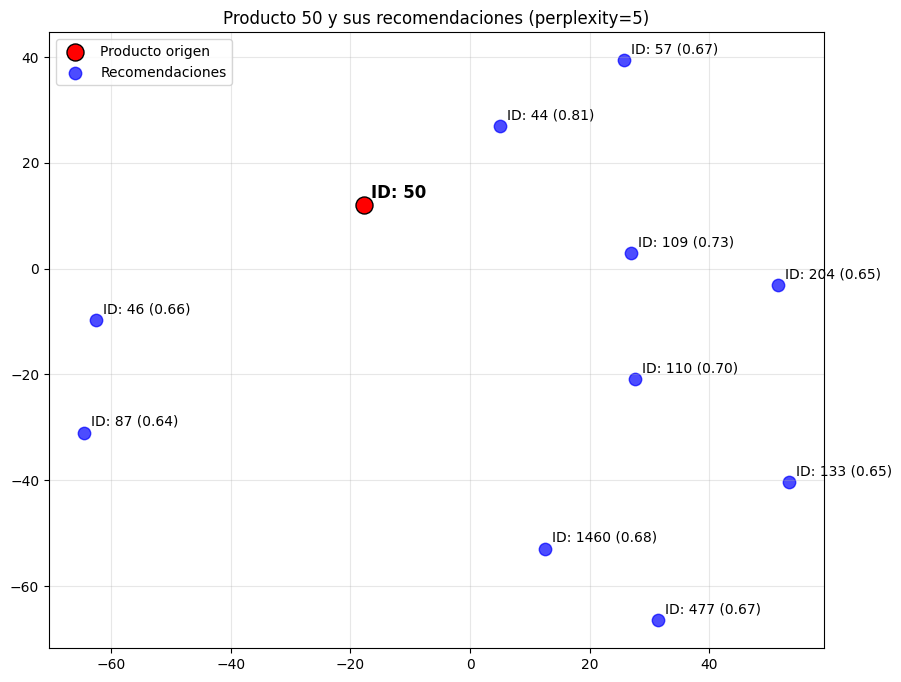

In [34]:
def visualize_recommendations(product_id, recommendations, embeddings):
    ids = [product_id] + [r[0] for r in recommendations]
    embeddings_subset = embeddings[ids].detach().cpu().numpy()

    n_samples = len(ids)
    perplexity = min(n_samples - 1, 5)

    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)

    embeddings_2d = tsne.fit_transform(embeddings_subset)

    plt.figure(figsize=(10, 8))
    plt.scatter(embeddings_2d[0, 0], embeddings_2d[0, 1], c='red', s=150, edgecolors='black', label='Producto origen')

    plt.scatter(embeddings_2d[1:, 0], embeddings_2d[1:, 1], c='blue', s=80, alpha=0.7, label='Recomendaciones')

    for i, (x, y) in enumerate(embeddings_2d):
        if i == 0:
            plt.annotate(f"ID: {ids[i]}", (x, y), xytext=(5, 5), textcoords="offset points", fontsize=12, fontweight='bold')
        else:
            plt.annotate(f"ID: {ids[i]} ({recommendations[i-1][1]:.2f})", (x, y), xytext=(5, 5), textcoords="offset points")

    plt.title(f"Producto {product_id} y sus recomendaciones (perplexity={perplexity})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

visualize_recommendations(example_product, recommendations, node_embeddings)

In [2]:
def visualize_network_graph(product_id, recommendations):

    G = nx.Graph()
    G.add_node(product_id, node_type='origin')

    for rec_id, similarity_score in recommendations:
        G.add_node(rec_id, node_type='recommendation')
        G.add_edge(product_id, rec_id, weight=similarity_score)

    plt.figure(figsize=(12, 10))

    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

    origin_nodes = [node for node, attr in G.nodes(data=True) if attr['node_type'] == 'origin']
    rec_nodes = [node for node, attr in G.nodes(data=True) if attr['node_type'] == 'recommendation']

    nx.draw_networkx_nodes(G, pos, nodelist=origin_nodes, node_color='red',
                          node_size=800, alpha=0.9, edgecolors='black', linewidths=2)
    nx.draw_networkx_nodes(G, pos, nodelist=rec_nodes, node_color='lightblue',
                          node_size=400, alpha=0.8, edgecolors='navy', linewidths=1)

    edges = G.edges(data=True)
    weights = [edge[2]['weight'] for edge in edges]

    max_weight = max(weights)
    min_weight = min(weights)
    normalized_weights = [(w - min_weight) / (max_weight - min_weight) * 5 + 1 for w in weights]

    nx.draw_networkx_edges(G, pos, width=normalized_weights, alpha=0.6, edge_color='gray')

    labels = {node: f"ID: {node}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

    edge_labels = {}
    for edge in edges:
        edge_labels[(edge[0], edge[1])] = f"{edge[2]['weight']:.2f}"

    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    plt.title(f"Red de Recomendaciones para Producto {product_id}", fontsize=16, fontweight='bold')
    plt.axis('off')

    legend_elements = [
        Patch(facecolor='red', edgecolor='black', label='Producto Origen'),
        Patch(facecolor='lightblue', edgecolor='navy', label='Recomendaciones'),
        plt.Line2D([0], [0], color='gray', linewidth=3, label='Similitud (grosor ∝ score)')
    ]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

visualize_network_graph(example_product, recommendations)

NameError: name 'example_product' is not defined